### Data Import

In [1]:
# Imports & Set Path
import numpy as np
import pandas as pd
from pathlib import Path
import time, os

# Import data
IN_URL = "https://data.austintexas.gov/resource/wter-evkm.csv"
OUT_URL = "https://data.austintexas.gov/resource/9t4d-g238.csv"

raw_dir = Path("..") / "data"
raw_dir.mkdir(parents=True, exist_ok=True)

# Read in full data (large data with more than 10k rows)
# It doesn't work well with setting URL="...?$limit=...", so use fetch socrata instead.
def fetch_socrata_to_csv(base_url, csv, limit=50000, max_rows=None):
    """
    pagination from Socrata to CSV
    - Resumable download: If CSV already exists, resume writing from the current row count
    """
    start_offset = 0
    if Path(csv).exists():
        try:
            start_offset = max(sum(1 for _ in open(csv, "r", encoding="utf-8")) -1, 0)
            print(f"[Resume] Found existing {csv}, rows={start_offset}. Will continue from offset={start_offset}.")
        except Exception as e:
            print("Resume check failed:", e)
            start_offset = 0

    offset = start_offset
    total_written = start_offset
    t0 = time.time()
    header_written = Path(csv).exists() and start_offset > 0

    while True:
        url = f"{base_url}?$limit={limit}&$offset={offset}"
        try:
            chunk = pd.read_csv(url)
        except Exception as e:
            print(f"\nError fetching offset={offset}: {e}")
            print("Will retry in 5s ...")
            time.sleep(5)
            continue

        n = len(chunk)
        if n == 0:
            break

        chunk.to_csv(csv, mode="a" if header_written else "w", index=False, header=not header_written)
        header_written = True

        offset += n
        total_written += n

        dt = time.time() - t0
        speed = total_written / max(dt,1)
        print(f"\rFetched & saved: {total_written} rows (last chunk={n}, ~{speed:.1f} rows/s)", end="")

        if max_rows is not None and total_written >= max_rows:
            print("\nReached max_rows limit; stopping early.")
            break

        if n < limit:
            break

    print("\nDone ->", csv)
    return total_written

def count_csv_rows(path):
    with open(path, "r", encoding="utf-8") as f:
        return max(sum(1 for _ in f) - 1, 0)

in_csv = raw_dir / "intakes.csv"
out_csv = raw_dir / "outcomes.csv"

# Download the data
# Intakes
if not in_csv.exists():
    print(f"[Download] {in_csv} not found. Start downloading intakes data ...")
    rows_in = fetch_socrata_to_csv(IN_URL, in_csv, limit=50000)
else:
    print(f"[Skip] {in_csv} already exists. Skip downloading.")
    rows_in = count_csv_rows(in_csv)

# Outcomes
if not out_csv.exists():
    print(f"[Download] {out_csv} not found. Start downloading outcomes data ...")
    rows_out = fetch_socrata_to_csv(OUT_URL, out_csv, limit=50000)
else:
    print(f"[Skip] {out_csv} already exists. Skip downloading.")
    rows_out = count_csv_rows(out_csv)

print("Rows (intakes):", rows_in)
print("Rows (outcomes):", rows_out)

# Read csv to dataframe
df_in = pd.read_csv(in_csv)
df_out = pd.read_csv(out_csv)
print("Intakes shape: ", df_in.shape)
print("Outcomes shape: ", df_out.shape)

[Skip] ../data/intakes.csv already exists. Skip downloading.
[Skip] ../data/outcomes.csv already exists. Skip downloading.
Rows (intakes): 173812
Rows (outcomes): 173775
Intakes shape:  (173812, 12)
Outcomes shape:  (173775, 12)


In [2]:
# Take a look at the data
display(df_in.head(3))
display(df_out.head(3))

,animal_id,name,datetime,datetime2,found_location,intake_type,intake_condition,animal_type,sex_upon_intake,age_upon_intake,breed,color
0,A521520,Nina,2013-10-01T07:51:00.000,2013-10-01T07:51:00.000,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White


,animal_id,date_of_birth,name,datetime,monthyear,outcome_type,outcome_subtype,animal_type,sex_upon_outcome,age_upon_outcome,breed,color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green


### Data Cleaning

In [3]:
# Data Cleaning
# 1) convert time to UTC, then drop timezone (naive timestamps)
def to_utc_naive(series):
    ts = pd.to_datetime(series, errors='coerce', utc=True)
    return ts.dt.tz_localize(None)

df_in["intake_ts"] = to_utc_naive(df_in["datetime"])
df_out["outcome_ts"] = to_utc_naive(df_out["datetime"])

# 2) convert age strings to a continuous feature 'days'
def age_to_days(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    parts = s.split()
    if len(parts) < 2:
        return np.nan

    try:
        n = float(parts[0])
    except:
        return np.nan
        
    unit = parts[1]
    if "day" in unit: return n
    if "week" in unit: return n * 7
    if "month" in unit: return n * 30
    if "year" in unit: return n * 365
    return np.nan

df_in["age_upon_intake_days"] = df_in["age_upon_intake"].map(age_to_days)
df_out["age_upon_outcome_days"] = df_out["age_upon_outcome"].map(age_to_days)

# 3) Use monthyear to fill missing outcome_ts when possible
# This is safe because outcome_ts will not be used in the feature matrix and will not cause data leakage.
if "monthyear" in df_out.columns:
    missing_out = df_out["outcome_ts"].isna() & df_out["monthyear"].notna()
    if missing_out.any():
        m = pd.to_datetime(
            df_out.loc[missing_out, "monthyear"],
            format="%m-%Y",
            errors="coerce",
            utc=True,
        )
        df_out.loc[missing_out, "outcome_ts"] = m.dt.tz_localize(None)
        

intake_valid_ratio = df_in["intake_ts"].notna().mean()
outcome_valid_ratio = df_out["outcome_ts"].notna().mean()

print(f"Intake timestamps successfully parsed: {intake_valid_ratio:.2%}")
print(f"Outcome timestamps successfully parsed: {outcome_valid_ratio:.2%}")

Intake timestamps successfully parsed: 100.00%
Outcome timestamps successfully parsed: 100.00%


In [4]:
# Combine timeline & Ingroup bfill
aid      = "animal_id"
time_in  = "intake_ts" 
time_out = "outcome_ts"

# 1) Keep only the necessary columns to reduce memory
in_keep = [c for c in [
    aid, time_in,
    "name","found_location","intake_type","intake_condition","animal_type",
    "sex_upon_intake","age_upon_intake","age_upon_intake_days","breed","color"
] if c in df_in.columns]

out_keep = [c for c in [
    aid, time_out,
    "outcome_type","outcome_subtype","animal_type","sex_upon_outcome",
    "age_upon_outcome","age_upon_outcome_days","breed","color"
] if c in df_out.columns]

df_in_  = df_in[in_keep].copy()
df_out_ = df_out[out_keep].copy()

# 2) Unify dtype
df_in_[aid]   = df_in_[aid].astype(str)
df_out_[aid]  = df_out_[aid].astype(str)
df_in_[time_in]   = pd.to_datetime(df_in_[time_in],  errors="coerce")
df_out_[time_out] = pd.to_datetime(df_out_[time_out], errors="coerce")

df_in_  = df_in_.dropna(subset=[aid, time_in]).copy()
df_out_ = df_out_.dropna(subset=[aid, time_out]).copy()

# 3) Add prefix out_ for outcomes & Rename time column to event_ts
df_in_  = df_in_.rename(columns={time_in: "event_ts"})
df_out_ = df_out_.rename(columns={time_out: "event_ts"})
df_out_ = df_out_.rename(columns={c: f"out_{c}" for c in df_out_.columns if c not in [aid, "event_ts"]})

# make sure there is an out_ column in df_in_ (use NaN as a placeholder first)
for c in [c for c in df_out_.columns if c.startswith("out_")]:
    if c not in df_in_.columns:
        df_in_[c] = np.nan

# 4) Combine timeline (intakes + outcomes for each animal, sorted by time)
df_in_["__kind__"]  = "intake"
df_out_["__kind__"] = "outcome"

common_cols = sorted(set(df_in_.columns) | set(df_out_.columns))
union_cols = [aid, "event_ts", "__kind__"] + [c for c in common_cols if c not in [aid, "event_ts", "__kind__"]]

df_in_aligned  = df_in_.reindex(columns=union_cols)
df_out_aligned = df_out_.reindex(columns=union_cols)

timeline = pd.concat([df_in_aligned, df_out_aligned], ignore_index=True)
timeline.sort_values([aid, "event_ts"], inplace=True, kind="mergesort")
timeline.reset_index(drop=True, inplace=True)

# 5) Ingroup bfill: for each animal, attach the NEXT outcome info to earlier rows
timeline["outcome_ts_tmp"] = np.where(timeline["__kind__"] == "outcome", timeline["event_ts"], pd.NaT)

out_cols = [c for c in timeline.columns if c.startswith("out_")] + ["outcome_ts_tmp"]

for c in out_cols:
    timeline[c] = timeline.groupby(aid, group_keys=False)[c].bfill()

# 6) Keep only intake rows: each row = one intake + its first future outcome (if any)
df_pair = timeline[timeline["__kind__"] == "intake"].copy()
df_pair.rename(columns={"event_ts":"intake_ts", "outcome_ts_tmp":"out_outcome_ts"}, inplace=True)

# 7) Calculate in-shelter time & Remove negatives (for EDA only)
df_pair["intake_ts"] = pd.to_datetime(df_pair["intake_ts"], errors="coerce")
df_pair["out_outcome_ts"] = pd.to_datetime(df_pair["out_outcome_ts"], errors="coerce")

mask = df_pair["intake_ts"].notna() & df_pair["out_outcome_ts"].notna()
df_pair.loc[mask, "shelter_days"] = (
    (df_pair.loc[mask, "out_outcome_ts"].values - df_pair.loc[mask, "intake_ts"].values)
    / np.timedelta64(1, "D")
)
df_pair.loc[~mask, "shelter_days"] = np.nan

neg = (df_pair["shelter_days"] < 0).sum(skipna=True)
if neg:
    print(f"Found {neg} rows with shelter_days < 0; excluded.")
    df_pair = df_pair[(df_pair["shelter_days"].isna()) | (df_pair["shelter_days"] >= 0)].copy()

# 9) Drop intakes that have no future outcome
unmatched_mask = df_pair["out_outcome_ts"].isna()
df_pair_model = df_pair[~unmatched_mask].copy()

unmatched_ratio = unmatched_mask.mean()
matched_ratio = 1 - unmatched_ratio

print("df_pair shape:", df_pair.shape, "| df_pair_model shape:", df_pair_model.shape)
print(f"Matched ratio: {matched_ratio:.2%} | Unmatched ratio: {unmatched_ratio:.2%}")

# 10) Take a look at df_pair and df_pair_model
print("\nPreview df_pair:")
display(df_pair.head(3))

print("\nPreview df_pair_model for ML:")
display(df_pair_model.head(3))
df_pair_model.columns.tolist()

df_pair shape: (173812, 23) | df_pair_model shape: (73557, 23)
Matched ratio: 42.32% | Unmatched ratio: 57.68%

Preview df_pair:


,animal_id,intake_ts,__kind__,age_upon_intake,age_upon_intake_days,animal_type,breed,color,found_location,intake_condition,...,out_age_upon_outcome_days,out_animal_type,out_breed,out_color,out_outcome_subtype,out_outcome_type,out_sex_upon_outcome,sex_upon_intake,out_outcome_ts,shelter_days
1,A006100,2014-03-07 14:26:00,intake,6 years,2190.0,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,...,2555.0,Dog,Spinone Italiano Mix,Yellow/White,NaN,Return to Owner,Neutered Male,Neutered Male,2014-12-01 00:00:00,268.398611
3,A006100,2014-12-19 10:21:00,intake,7 years,2555.0,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,...,3650.0,Dog,Spinone Italiano Mix,Yellow/White,NaN,Return to Owner,Neutered Male,Neutered Male,2017-12-07 05:00:00,1083.777083
5,A006100,2017-12-07 14:07:00,intake,10 years,3650.0,Dog,Spinone Italiano Mix,Yellow/White,Colony Creek And Hunters Trace in Austin (TX),Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neutered Male,NaT,NaN



Preview df_pair_model for ML:


,animal_id,intake_ts,__kind__,age_upon_intake,age_upon_intake_days,animal_type,breed,color,found_location,intake_condition,...,out_age_upon_outcome_days,out_animal_type,out_breed,out_color,out_outcome_subtype,out_outcome_type,out_sex_upon_outcome,sex_upon_intake,out_outcome_ts,shelter_days
1,A006100,2014-03-07 14:26:00,intake,6 years,2190.0,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,...,2555.0,Dog,Spinone Italiano Mix,Yellow/White,NaN,Return to Owner,Neutered Male,Neutered Male,2014-12-01 00:00:00,268.398611
3,A006100,2014-12-19 10:21:00,intake,7 years,2555.0,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,...,3650.0,Dog,Spinone Italiano Mix,Yellow/White,NaN,Return to Owner,Neutered Male,Neutered Male,2017-12-07 05:00:00,1083.777083
26,A200922,2013-10-03 15:47:00,intake,16 years,5840.0,Dog,Dachshund Mix,Black/Tan,Austin (TX),Normal,...,5840.0,Dog,Dachshund Mix,Black/Tan,Foster,Adoption,Neutered Male,Neutered Male,2013-11-01 00:00:00,28.342361


['animal_id',
 'intake_ts',
 '__kind__',
 'age_upon_intake',
 'age_upon_intake_days',
 'animal_type',
 'breed',
 'color',
 'found_location',
 'intake_condition',
 'intake_type',
 'name',
 'out_age_upon_outcome',
 'out_age_upon_outcome_days',
 'out_animal_type',
 'out_breed',
 'out_color',
 'out_outcome_subtype',
 'out_outcome_type',
 'out_sex_upon_outcome',
 'sex_upon_intake',
 'out_outcome_ts',
 'shelter_days']

### EDA

Raw outcome_type distribution:


,count
outcome_raw,
Adoption,50629
Transfer,13791
Return to Owner,6436
Euthanasia,1337
Rto-Adopt,658
Died,480
Disposal,120
Missing,83
nan,15


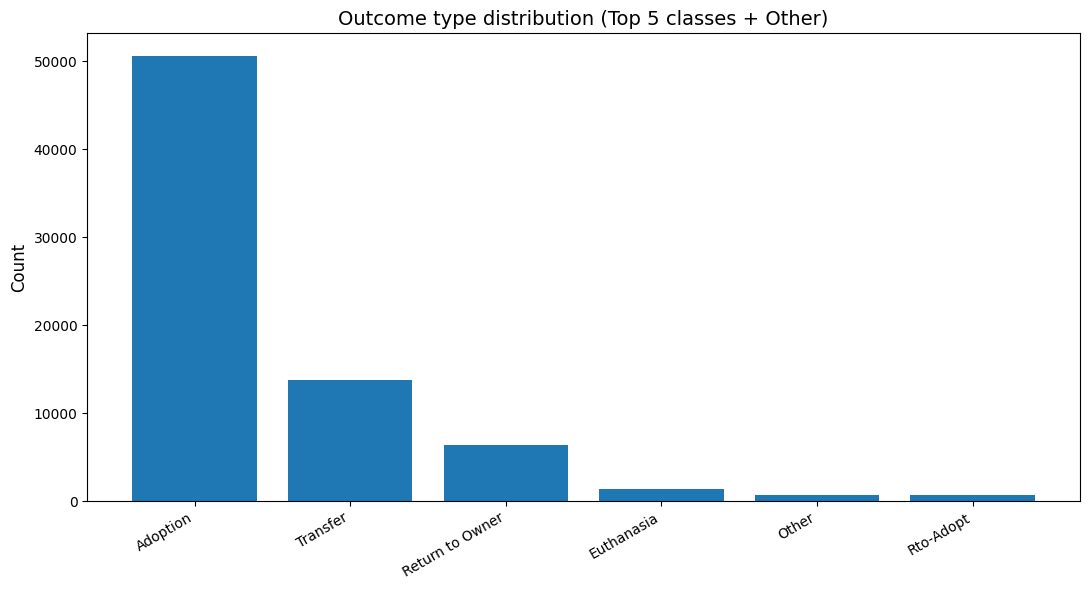

Saved: ../figures/bar_outcome_eda_distribution.png


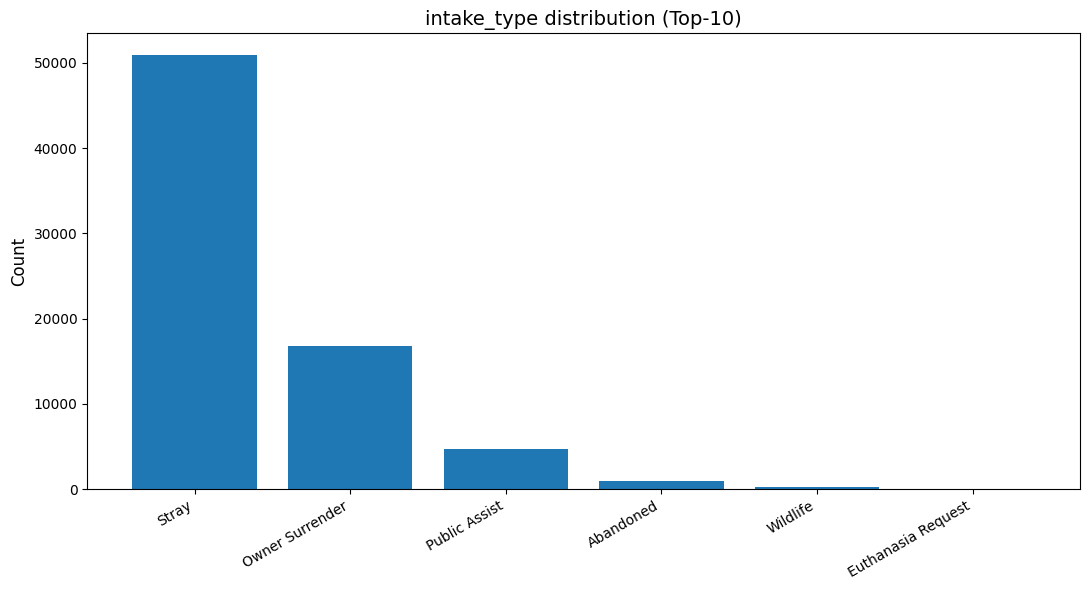

Saved: ../figures/bar_intake_type_top10.png


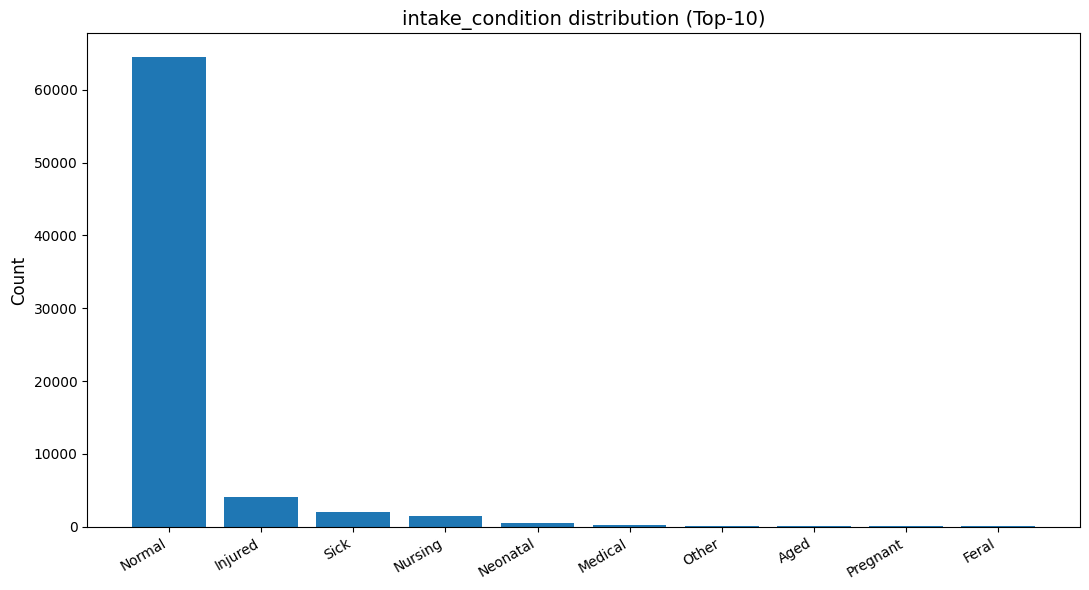

Saved: ../figures/bar_intake_condition_top10.png


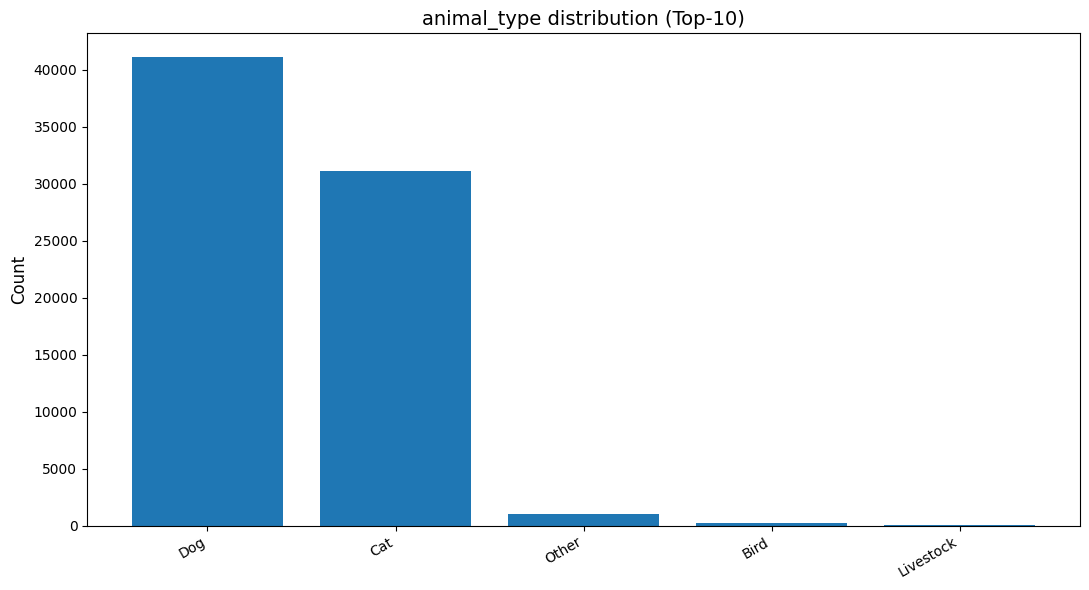

Saved: ../figures/bar_animal_type_top10.png


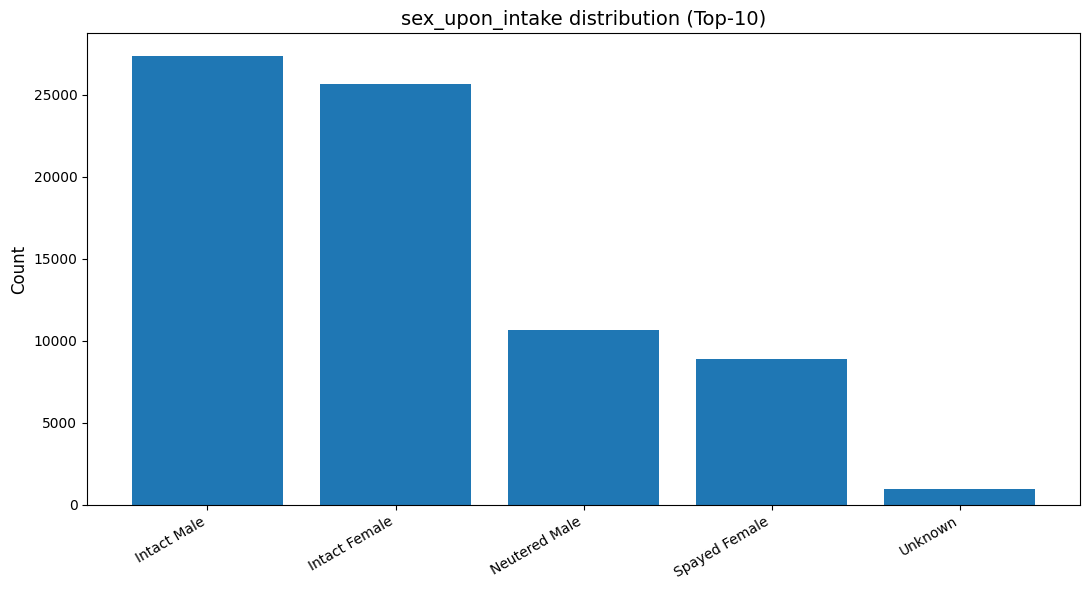

Saved: ../figures/bar_sex_upon_intake_top10.png

breed value_counts (Top-20):


breed
Domestic Shorthair Mix       14374
Domestic Shorthair           11642
Pit Bull Mix                  5890
Labrador Retriever Mix        4033
Chihuahua Shorthair Mix       2351
Pit Bull                      2005
German Shepherd Mix           1831
Domestic Medium Hair Mix      1435
Domestic Medium Hair          1066
Australian Cattle Dog Mix      951
Labrador Retriever             855
German Shepherd                834
Domestic Longhair Mix          735
Chihuahua Shorthair            620
Siamese Mix                    617
Boxer Mix                      577
Border Collie Mix              505
Staffordshire Mix              499
Catahoula Mix                  443
Siberian Husky Mix             428
Name: count, dtype: int64


color value_counts (Top-20):


color
Black/White            8306
Black                  6303
Brown Tabby            4857
Blue/White             2547
Brown/White            2537
Brown Tabby/White      2512
White                  2260
Tan/White              2215
Orange Tabby           2213
White/Black            2192
Brown                  1715
Tan                    1592
Brown Brindle/White    1542
White/Brown            1509
Tortie                 1478
Black/Brown            1467
Blue                   1440
Black/Tan              1434
Tricolor               1406
Calico                 1368
Name: count, dtype: int64

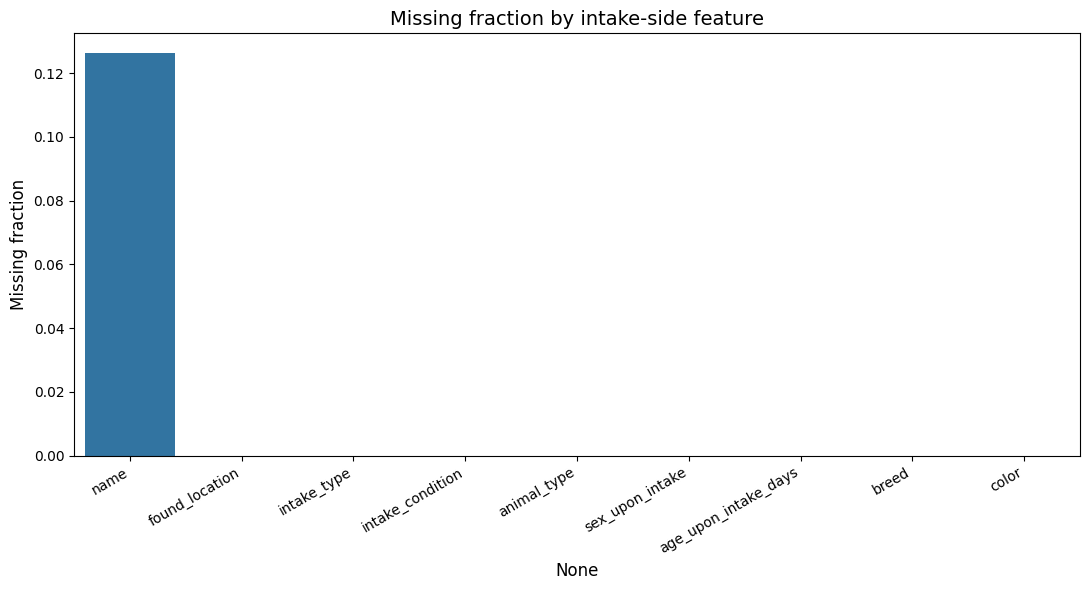

Saved: ../figures/bar_missing_fraction_intake_features.png

Missing value counts for intake-side features:


,n_missing
name,9279
found_location,0
intake_type,0
intake_condition,0
animal_type,0
sex_upon_intake,0
age_upon_intake_days,0
breed,0
color,0


name: NA=0.1261, blank=0.0000, 'unknown'=0.0001
found_location: NA=0.0000, blank=0.0000, 'unknown'=0.0000
intake_type: NA=0.0000, blank=0.0000, 'unknown'=0.0000
intake_condition: NA=0.0000, blank=0.0000, 'unknown'=0.0002
animal_type: NA=0.0000, blank=0.0000, 'unknown'=0.0000
sex_upon_intake: NA=0.0000, blank=0.0000, 'unknown'=0.0134
age_upon_intake_days: NA=0.0000, blank=0.0000, 'unknown'=0.0000
breed: NA=0.0000, blank=0.0000, 'unknown'=0.0000
color: NA=0.0000, blank=0.0000, 'unknown'=0.0000


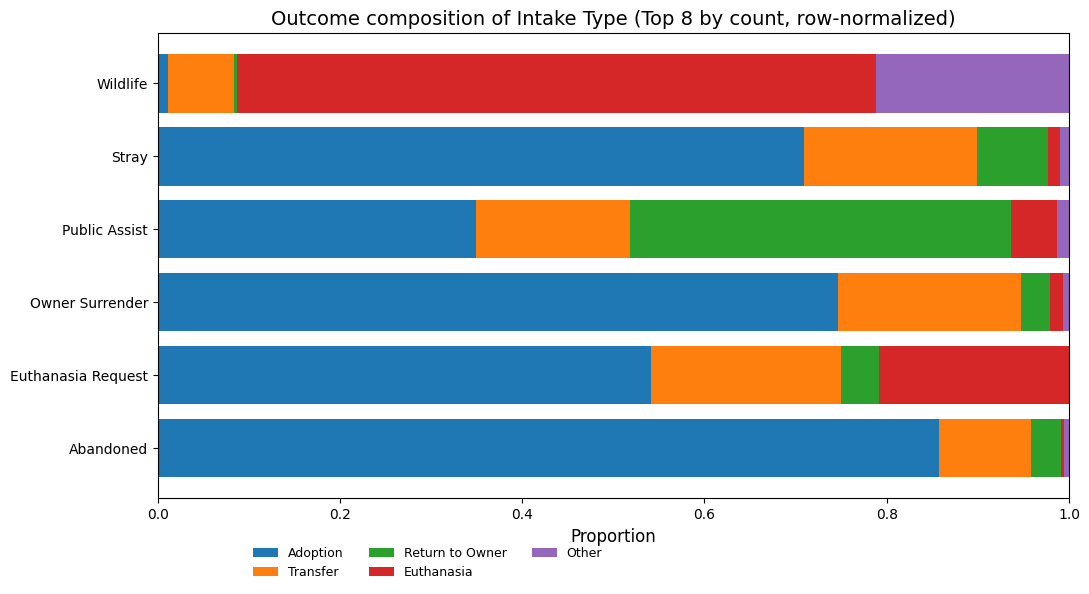

Saved: ../figures/stacked_intake_type_outcomes_normalized.png


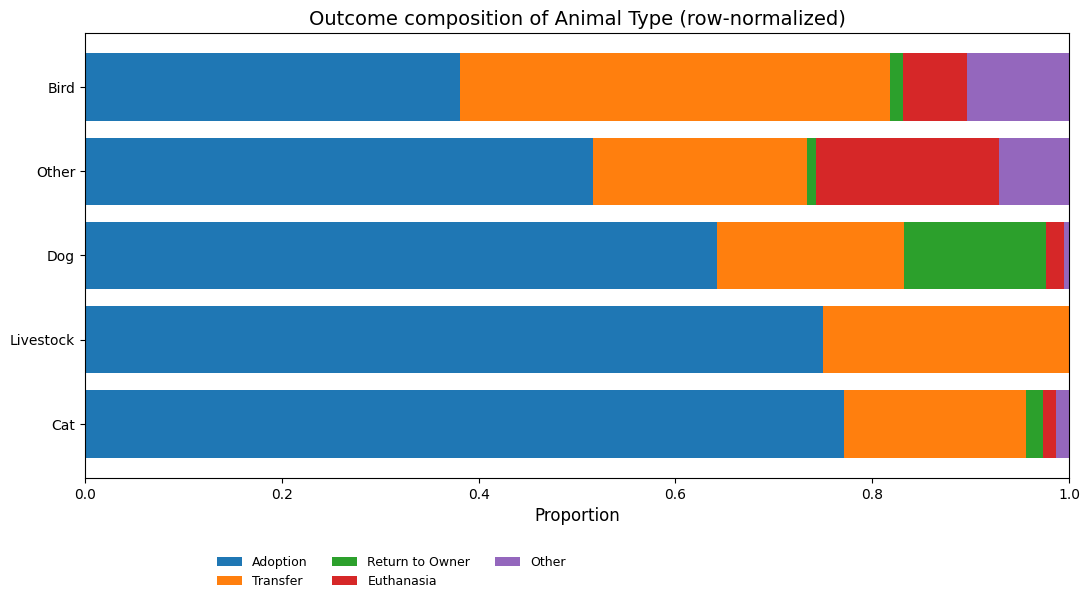

Saved: ../figures/stacked_animal_type_outcomes_normalized.png


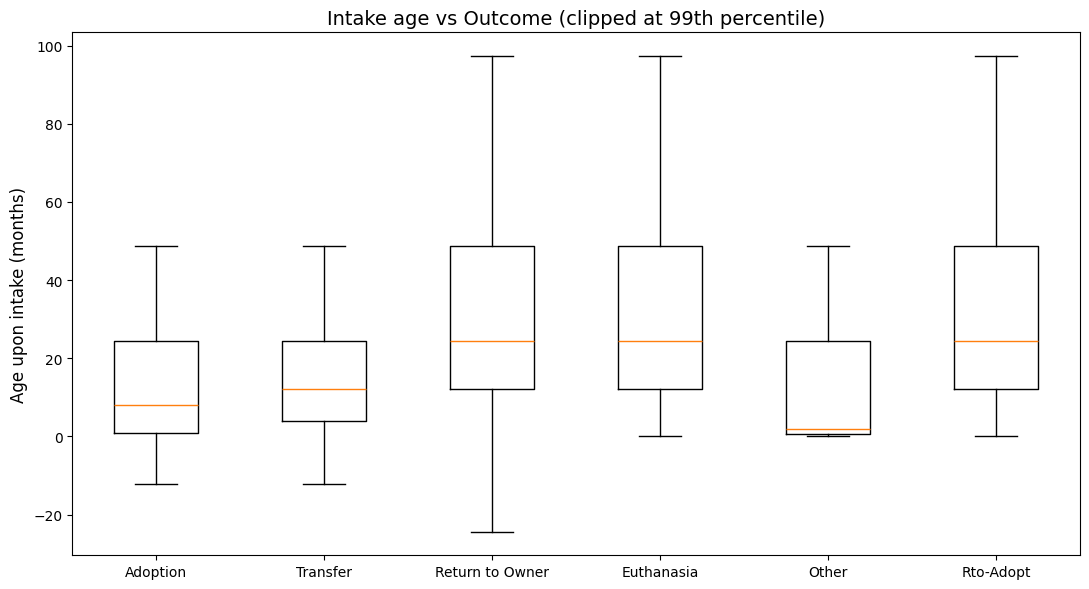

Saved: ../figures/box_intake_age_by_outcome.png


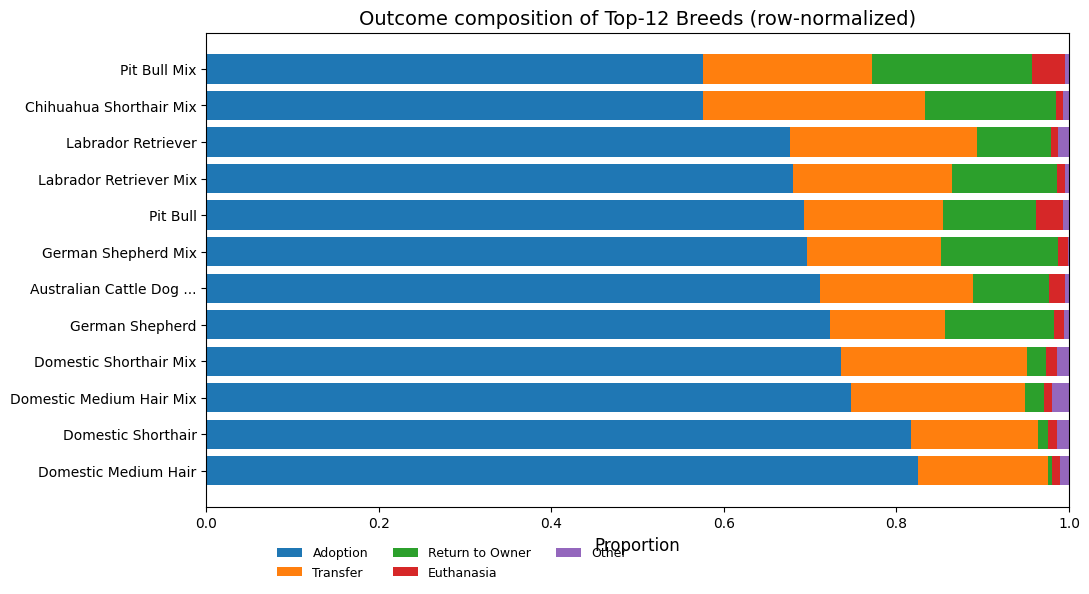

Saved: ../figures/stacked_breed_outcomes_normalized.png


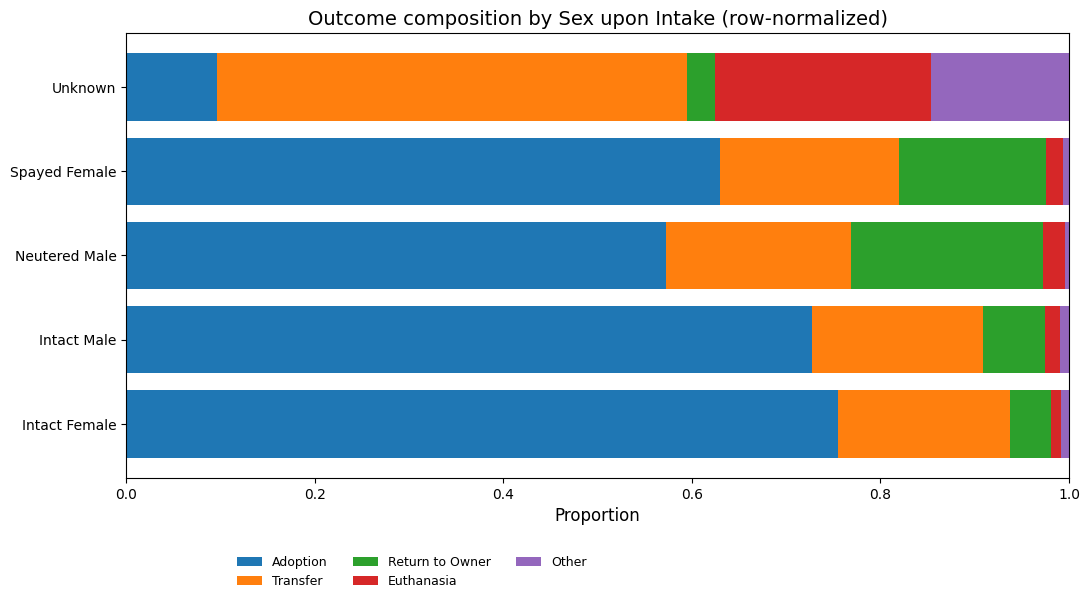

Saved: ../figures/stacked_sex_upon_intake_outcomes_normalized.png


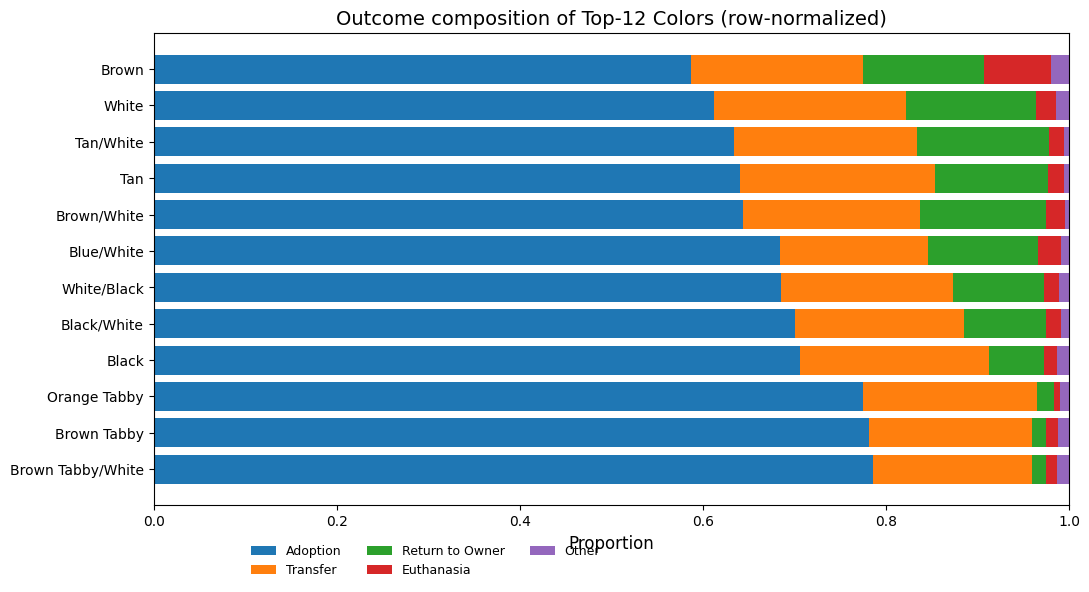

Saved: ../figures/stacked_color_outcomes_normalized.png


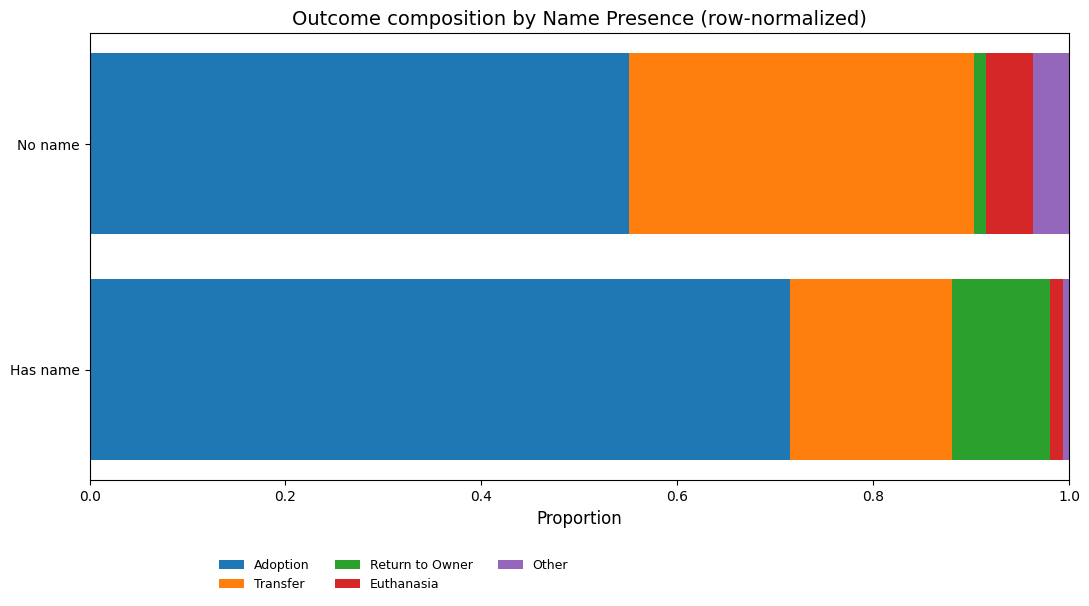

Saved: ../figures/stacked_has_name_outcomes_normalized.png


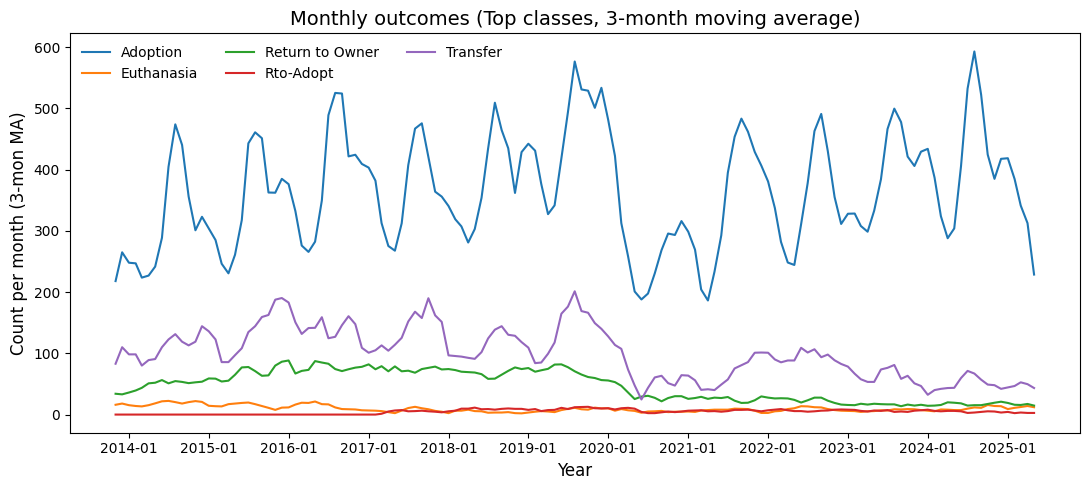

Saved: ../figures/line_monthly_outcomes_top.png


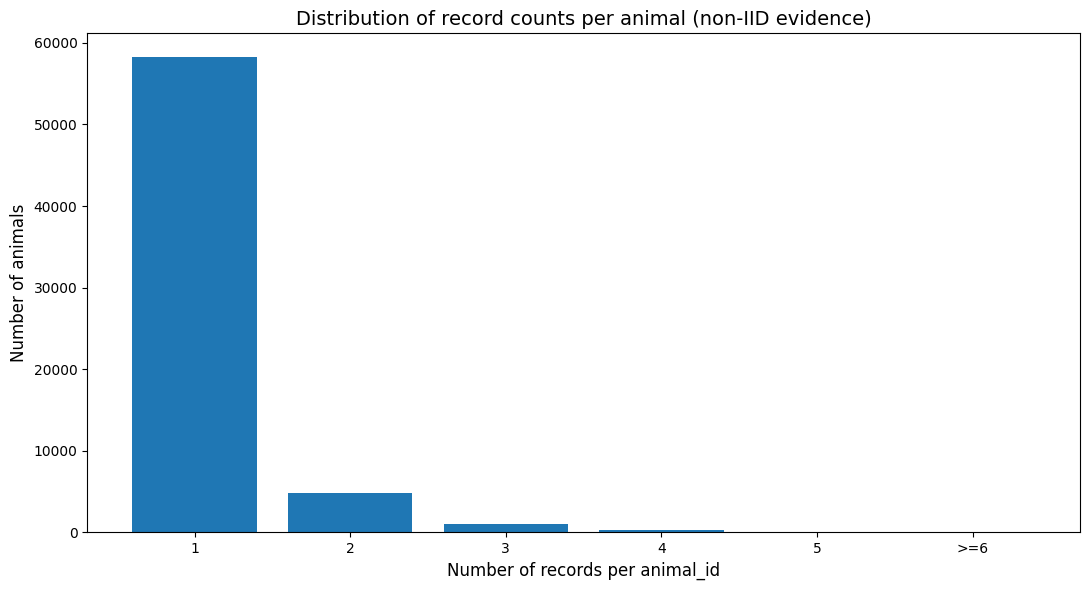

Saved: ../figures/bar_records_per_animal_grouped.png


In [5]:
# EDA Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# set up EDA dataframe
eda = df_pair_model.copy()
eda["outcome_raw"] = eda["out_outcome_type"].astype(str).str.strip()

if "name" in eda.columns:
    eda["has_name"] = (~eda["name"].isna() & eda["name"].astype(str).str.strip().ne(""))

# set up figure path
fig_dir = Path("..") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (11,6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

def save_show_plt(figpath):
    plt.tight_layout()
    plt.savefig(figpath, dpi=300)
    plt.show()
    print("Saved:", figpath)

def norm_crosstab(df, row, col, topk_rows=None, topk_cols=None):
    """
    return crosstab plot normalized by row；
    Select the top k classes from the row
    """
    tmp = df.copy()
    if topk_rows is not None:
        top_vals = tmp[row].value_counts().head(topk_rows).index
        tmp = tmp[tmp[row].isin(top_vals)]
    if topk_cols is not None:
        top_cls = tmp[col].value_counts().head(topk_cols).index
        tmp = tmp[tmp[col].isin(top_cls)]

    ct = pd.crosstab(tmp[row], tmp[col])
    ct = ct.div(ct.sum(axis=1), axis=0)  # row-normalized
    return ct

# ===================== A. Outcome EDA =====================
# 1) Raw outcome distribution (for deciding class grouping later)
outcome_counts = eda['outcome_raw'].value_counts()
print("Raw outcome_type distribution:")
display(outcome_counts.to_frame("count"))

# select top k outcomes, and combine the others into 'other'
top_k_outcome = 5
top_outcomes = outcome_counts.head(top_k_outcome).index.tolist()
eda['outcome_eda'] = np.where(
    eda['outcome_raw'].isin(top_outcomes),
    eda['outcome_raw'],
    "Other"
)

# 2) Bar plot: outcome_eda distribution
cls_counts = eda['outcome_eda'].value_counts().sort_values(ascending=False)
plt.figure()
x = np.arange(len(cls_counts))
plt.bar(x, cls_counts.values)
plt.xticks(x, cls_counts.index, rotation=30, ha='right')
plt.ylabel('Count')
plt.title("Outcome type distribution (Top 5 classes + Other)")
save_show_plt(fig_dir / "bar_outcome_eda_distribution.png")


# ===================== B. Intake-side feature distributions =====================
cat_features = ['intake_type', 'intake_condition', 'animal_type', 'sex_upon_intake']

def plot_cat_counts(df, col, topk=10, fname=None, title=None):
    vc = df[col].value_counts().head(topk)
    plt.figure()
    x = np.arange(len(vc))
    plt.bar(x, vc.values)
    plt.xticks(x, vc.index.astype(str), rotation=30, ha='right')
    plt.ylabel('Count')
    plt.title(title if title is not None else f"{col} distribution (Top-{topk})")
    if fname is not None:
        save_show_plt(fname)
    else:
        plt.tight_layout()
        plt.show()

for col in cat_features:
    if col in eda.columns:
        plot_cat_counts(
            eda.dropna(subset = [col]),
            col,
            topk = 10,
            fname = fig_dir / f"bar_{col}_top10.png",
            title = f"{col} distribution (Top-10)"
        )

# Breed / color frequency table
for col in ['breed', 'color']:
    if col in eda.columns:
        print(f"\n{col} value_counts (Top-20):")
        display(eda[col].value_counts().head(20))

# ===================== C. Missing value analysis =====================
intake_feature_cols = ["name", "found_location", "intake_type", "intake_condition", "animal_type", "sex_upon_intake", "age_upon_intake_days", "breed", "color"]

# missing ratio barplot for each feature
missing_df = eda[intake_feature_cols]
missing_ratio = missing_df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(11,6))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Missing fraction")
plt.title("Missing fraction by intake-side feature")
save_show_plt(fig_dir / "bar_missing_fraction_intake_features.png")

print("\nMissing value counts for intake-side features:")
display(missing_df.isna().sum().to_frame("n_missing"))

# We find that there is only missing value in 'name' feature
# So we will take a look at the proportion of values already being marked as a string 'unknown' or an empty string
for col in intake_feature_cols:
    s = eda[col].astype(str).str.strip()
    frac_na = eda[col].isna().mean()
    frac_blank = (s == "").mean()
    frac_unknown = s.str.lower().eq("unknown").mean()
    print(f"{col}: NA={frac_na:.4f}, blank={frac_blank:.4f}, 'unknown'={frac_unknown:.4f}")

# ===================== D. Feature vs Outcome (category-level) =====================
# 1) Intake type vs outcome (stacked bar, normalized)
if "intake_type" in eda.columns:
    ct_intake = norm_crosstab(
        eda.dropna(subset=["intake_type"]),
        row = "intake_type",
        col = "outcome_eda",
        topk_rows = 8,
        topk_cols = top_k_outcome
    )

    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_intake = ct_intake.reindex(columns=[c for c in cls_order if c in ct_intake.columns])

    labels = [s if len(s) <= 20 else s[:18] + "-" for s in ct_intake.index]
    ypos = np.arange(len(ct_intake))

    plt.figure(figsize=(11,6))
    bottom = np.zeros(len(ct_intake))
    for c in ct_intake.columns:
        plt.barh(ypos, ct_intake[c].values, left=bottom, label=c)
        bottom += ct_intake[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition of Intake Type (Top 8 by count, row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.08))
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    save_show_plt(fig_dir / "stacked_intake_type_outcomes_normalized.png")

# 2) Animal type vs outcome (stacked bar, normalized)
if "animal_type" in eda.columns:
    df_at = eda.dropna(subset=["animal_type"]).copy()
    ct_at = norm_crosstab(
        df_at,
        row = "animal_type",
        col = "outcome_eda",
        topk_rows = None,
        topk_cols = top_k_outcome
    )

    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_at = ct_at.reindex(columns=[c for c in cls_order if c in ct_at.columns])

    if "Adoption" in ct_at.columns:
        ct_at = ct_at.sort_values(by="Adoption", ascending=False)

    labels = ct_at.index.tolist()
    ypos = np.arange(len(ct_at))

    plt.figure(figsize=(11,6))
    bottom = np.zeros(len(ct_at))
    for c in ct_at.columns:
        plt.barh(ypos, ct_at[c].values, left=bottom, label=c)
        bottom += ct_at[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition of Animal Type (row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    save_show_plt(fig_dir / "stacked_animal_type_outcomes_normalized.png")

# 3) Intake age vs outcome (box plot, clipped at 99th percentile)
if "age_upon_intake_days" in eda.columns:
    eda["age_months"] = eda["age_upon_intake_days"] / 30.0
    hi = np.nanpercentile(eda["age_months"], 99)
    sub = eda[(eda["age_months"] <= hi)].dropna(subset=["age_months"])

    order = sub["outcome_eda"].value_counts().index.tolist()
    data = [sub.loc[sub["outcome_eda"] == c, "age_months"].values for c in order if len(sub.loc[sub["outcome_eda"] == c]) >= 20]
    labels = [c for c in order if len(sub.loc[sub["outcome_eda"] == c]) >= 20]

    if len(labels) >= 2:
        plt.figure(figsize=(11,6))
        plt.boxplot(data, tick_labels=labels, showfliers=False)
        plt.ylabel("Age upon intake (months)")
        plt.title("Intake age vs Outcome (clipped at 99th percentile)")
        save_show_plt(fig_dir / "box_intake_age_by_outcome.png")
    else:
        print("Skip age boxplot: not enough categories with data.")

# 4） Breed vs outcome (Top-12 breeds, row-normalized)
if "breed" in eda.columns:
    df_breed = eda.dropna(subset=["breed"]).copy()
    
    ct_breed = norm_crosstab(
        df_breed,
        row = "breed",
        col = "outcome_eda",
        topk_rows = 12,
        topk_cols = top_k_outcome
    )

    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_breed = ct_breed.reindex(columns=[c for c in cls_order if c in ct_breed.columns])

    if "Adoption" in ct_breed.columns:
        ct_breed = ct_breed.sort_values(by="Adoption", ascending=False)

    labels = [s if len(s) <= 24 else s[:22] + "..." for s in ct_breed.index]
    ypos = np.arange(len(ct_breed))

    plt.figure(figsize=(11,6))
    bottom = np.zeros(len(ct_breed))
    for c in ct_breed.columns:
        plt.barh(ypos, ct_breed[c].values, left=bottom, label=c)
        bottom += ct_breed[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition of Top-12 Breeds (row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    save_show_plt(fig_dir / "stacked_breed_outcomes_normalized.png")

# 5) Intake sex vs outcome (row-normalized stacked bar)
if "sex_upon_intake" in eda.columns:
    df_sex = eda.dropna(subset=["sex_upon_intake"]).copy()
    ct_sex = norm_crosstab(
        df_sex,
        row="sex_upon_intake",
        col="outcome_eda",
        topk_rows=None,
        topk_cols=top_k_outcome
    )
    
    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_sex = ct_sex.reindex(columns=[c for c in cls_order if c in ct_sex.columns])

    labels = ct_sex.index.astype(str).tolist()
    ypos = np.arange(len(ct_sex))

    plt.figure(figsize=(11, 6))
    bottom = np.zeros(len(ct_sex))
    for c in ct_sex.columns:
        plt.barh(ypos, ct_sex[c].values, left=bottom, label=c)
        bottom += ct_sex[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition by Sex upon Intake (row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    save_show_plt(fig_dir / "stacked_sex_upon_intake_outcomes_normalized.png")

# 6) Color vs outcome (Top-12 colors, row-normalized)
if "color" in eda.columns:
    df_color = eda.dropna(subset=["color"]).copy()
    ct_color = norm_crosstab(
        df_color,
        row="color",
        col="outcome_eda",
        topk_rows=12,
        topk_cols=top_k_outcome
    )
    
    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_color = ct_color.reindex(columns=[c for c in cls_order if c in ct_color.columns])

    if "Adoption" in ct_color.columns:
        ct_color = ct_color.sort_values(by="Adoption", ascending=False)

    labels = [s if len(s) <= 24 else s[:22] + "..." for s in ct_color.index]
    ypos = np.arange(len(ct_color))

    plt.figure(figsize=(11,6))
    bottom = np.zeros(len(ct_color))
    for c in ct_color.columns:
        plt.barh(ypos, ct_color[c].values, left=bottom, label=c)
        bottom += ct_color[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition of Top-12 Colors (row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    save_show_plt(fig_dir / "stacked_color_outcomes_normalized.png")

# 7) Has-name vs outcome (row-normalized)
if "has_name" in eda.columns:
    df_nameflag = eda.dropna(subset=["has_name"]).copy()
    df_nameflag["has_name_str"] = df_nameflag["has_name"].map({True: "Has name", False: "No name"})

    ct_name = norm_crosstab(
        df_nameflag,
        row="has_name_str",
        col="outcome_eda",
        topk_rows=None,
        topk_cols=top_k_outcome
    )

    cls_order = eda["outcome_eda"].value_counts().index.tolist()
    ct_name = ct_name.reindex(columns=[c for c in cls_order if c in ct_name.columns])

    labels = ct_name.index.tolist()
    ypos = np.arange(len(ct_name))

    plt.figure(figsize=(11,6))
    bottom = np.zeros(len(ct_name))
    for c in ct_name.columns:
        plt.barh(ypos, ct_name[c].values, left=bottom, label=c)
        bottom += ct_name[c].values

    plt.yticks(ypos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Proportion")
    plt.title("Outcome composition by Name Presence (row-normalized)")
    plt.legend(ncol=3, fontsize=9, frameon=False, loc="best", bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout(rect=[0, 0.15, 1, 1])
    save_show_plt(fig_dir / "stacked_has_name_outcomes_normalized.png")


# ===================== E. Time-related EDA =====================
if "out_outcome_ts" in eda.columns:
    monthly = eda.dropna(subset=["out_outcome_ts"]).copy()
    monthly["ym"] = pd.to_datetime(monthly["out_outcome_ts"]).dt.to_period("M").dt.to_timestamp()

    pivot = (monthly[monthly["outcome_eda"].isin(top_outcomes)]
        .pivot_table(index="ym", columns="outcome_eda", values="animal_id", aggfunc="count", fill_value=0)
        .sort_index())

    if len(pivot) > 0:
        pivot_ma = pivot.rolling(window=3, min_periods=1).mean()
        fig, ax = plt.subplots(figsize=(11,5))
        for c in pivot_ma.columns:
            ax.plot(pivot_ma.index, pivot_ma[c].values, label=c)

        span_years = (pivot_ma.index.max() - pivot_ma.index.min()).days / 365

        if span_years >= 3:
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        else:
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=6))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
        ax.set_xlabel("Year")
        ax.set_ylabel("Count per month (3-mon MA)")
        ax.set_title("Monthly outcomes (Top classes, 3-month moving average)")
        ax.legend(ncol=3, frameon=False, loc="upper left")
        plt.tight_layout()
        save_show_plt(fig_dir / "line_monthly_outcomes_top.png")

# ===================== F. Non-IID evidence: animal_id frequency =====================
if "animal_id" in eda.columns:
    counts_per_animal = eda["animal_id"].value_counts()
    vc = counts_per_animal.value_counts().sort_index()

    # combine >= 6 times to a tail to prevent x-axis too long
    max_small = 5
    vc_small = vc[vc.index <= max_small].copy()
    tail_count = vc[vc.index > max_small].sum()
    if tail_count > 0:
        vc_small.loc[max_small + 1] = tail_count
            
    plt.figure(figsize=(11,6))
    plt.bar(vc_small.index.astype(str), vc_small.values)
    labels = [str(k) if k <= max_small else ">=6" for k in vc_small.index]
    plt.xticks(vc_small.index.astype(str), labels)
    plt.xlabel("Number of records per animal_id")
    plt.ylabel("Number of animals")
    plt.title("Distribution of record counts per animal (non-IID evidence)")
    save_show_plt(fig_dir / "bar_records_per_animal_grouped.png")


### Data Splitting & Preprocessing

In [6]:
# Multi-class classification Labeling
# According to our EDA, the top outcome classes are: Adoption, Transfer, Return to Owner, Euthanasia
# And we will classify all the other minor outcomes into 'other'

out_type_col = "out_outcome_type"
assert out_type_col in df_pair_model.columns, "out_come_type not found."

# Clean raw outcome text
df_pair_model["outcome_raw"] = df_pair_model[out_type_col].astype(str).str.strip()

# Define desired major classes based on EDA
major_classes = ["Adoption", "Transfer", "Return to Owner", "Euthanasia"]

# Keep only classes that actually appear
present_major = [c for c in major_classes if c in df_pair_model["outcome_raw"].unique()]
print("Major classes present in data:", present_major)

# Map into multi-class
def map_outcome_multi(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return x if x in present_major else "Other"

df_pair_model["outcome_multi"] = df_pair_model["outcome_raw"].map(map_outcome_multi)

# Drop missing
df_pair_model = df_pair_model.dropna(subset=["outcome_multi"]).copy()

print("\nFinal outcome_multi distribution:")
print(df_pair_model["outcome_multi"].value_counts())
print("\nClasses:", sorted(df_pair_model["outcome_multi"].unique()))

Major classes present in data: ['Adoption', 'Transfer', 'Return to Owner', 'Euthanasia']

Final outcome_multi distribution:
outcome_multi
Adoption           50629
Transfer           13791
Return to Owner     6436
Other               1364
Euthanasia          1337
Name: count, dtype: int64

Classes: ['Adoption', 'Euthanasia', 'Other', 'Return to Owner', 'Transfer']


In [7]:
# Feature construction for multi-class model
import re
# 1) Target variable y
y = df_pair_model["outcome_multi"].copy()

# 2) Construct the final df for the model (use only the intake side info to prevent data leakage)
feat_cols_raw = [
    "animal_id", 
    "name",
    "found_location", 
    "animal_type", 
    "breed", 
    "color", 
    "intake_type", 
    "intake_condition", 
    "sex_upon_intake", 
    "age_upon_intake_days", 
    "intake_ts",
]

# make sure we don't miss any useful features
missing_cols = [c for c in feat_cols_raw if c not in df_pair_model.columns]
if missing_cols:
    print("Warning: the following expected columns are missing in df_pair_model:", missing_cols)

use_df = df_pair_model[[c for c in feat_cols_raw if c in df_pair_model.columns]].copy()

# 3a) use 'has_name' than 'name' feature
use_df["has_name"] = (
    ~use_df["name"].isna()
    & use_df["name"].astype(str).str.strip().ne("")
).astype(int)

# 3b) use found_location is precise or not instead of the whole complicated address
def is_precise_location(val):
    # treat NA as not a precise location
    if pd.isna(val):
        return 0
    s = str(val)
    # treat location as precise as long as it contains number
    return int(any(ch.isdigit() for ch in s))

if "found_location" in use_df.columns:
    use_df["location_is_precise"] = use_df["found_location"].apply(is_precise_location)
else:
    use_df["location_is_precise"] = 0

# 4) clean NaN / "" to "missing"
cat_cols_raw = [
    "animal_type",
    "breed",
    "color",
    "intake_type",
    "intake_condition",
    "sex_upon_intake",
]

def clean_categorical(s):
    s = s.astype("string")
    s = s.str.strip()
    s = s.mask(s == "", pd.NA)
    return s

for col in cat_cols_raw:
    if col in use_df.columns:
        use_df[col] = clean_categorical(use_df[col])

# 5) High-cardinality clip
def clip_rare(s, topk):
    vc = s.value_counts()
    keep = set(vc.head(topk).index)
    return s.where(s.isin(keep), "Other")

use_df["breed"] = clip_rare(use_df["breed"], topk=200)
use_df["color"] = clip_rare(use_df["color"], topk=150)

# 6) Time features (from intake_ts derive month / is_weekend)
ts = pd.to_datetime(use_df["intake_ts"], errors="coerce")
use_df["month"]      = ts.dt.month.astype("Int64").astype("string").fillna("missing")
use_df["is_weekend"] = ts.dt.dayofweek.isin([5,6]).astype(int)

# 7) Final feature matrix
cat_cols = ["animal_type","breed","color","intake_type","intake_condition","sex_upon_intake","month"]
num_cols = ["age_upon_intake_days"]
bin_cols = ["is_weekend", "has_name", "location_is_precise"]
group_col = "animal_id"

X = use_df[cat_cols + num_cols + bin_cols].copy()
groups = use_df[group_col].copy()

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Number of groups (animals):", groups.nunique())

X shape:  (73557, 11)
y shape:  (73557,)
Number of groups (animals): 64693


In [8]:
# Splitting & Preprocessing
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

In [9]:
# Group-based split: train/test = 80/20
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("n_train:", len(X_train), "n_test:", len(X_test))

n_train: 58880 n_test: 14677


In [10]:
# Data leakage check
overlap_train_test = set(groups_train) & set(groups_test)

print("Group leakage check:")
print("Train ∩ Test animals:", len(overlap_train_test))

Group leakage check:
Train ∩ Test animals: 0


In [11]:
# Preprocessing
# According to our EDA, only the 'name' feature has NAs, and no features have blank values.
def make_preprocessor(cat_cols, num_cols, bin_cols):
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='constant',fill_value='missing')),
        ('onehot', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
    ])

    num_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    bin_transformer = "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_transformer, cat_cols),
            ("num", num_transformer, num_cols),
            ("bin", bin_transformer, bin_cols)
        ]
    )
    return preprocessor

preprocessor = make_preprocessor(cat_cols, num_cols, bin_cols)

### ML Models

In [12]:
# Create a subsample to save hyperparameter tuning time (follow the groups)
def make_subsample(X, y, groups, n, random_state=42):
    df_idx = pd.DataFrame({"group": groups}, index=X.index)
    unique_groups = df_idx["group"].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_groups)

    select_idx = []
    total = 0
    for g in unique_groups:
        idx_g = df_idx.index[df_idx["group"] == g]
        select_idx.extend(idx_g.tolist())
        total += len(idx_g)
        if total >= n:
            break

    if len(select_idx) > n:
        selected_idx = selected_idx[:n]

    X_sub = X.loc[select_idx].copy()
    y_sub = y.loc[select_idx].copy()
    groups_sub = groups.loc[select_idx].copy()

    print(f"Subsample size: {X_sub.shape}")
    return X_sub, y_sub, groups_sub

X_sub, y_sub, groups_sub = make_subsample(X_train, y_train, groups_train, n=1000)

Subsample size: (1000, 11)


#### Param grids

In [34]:
# Logistic Regression
log_params = {
    "model__C": np.logspace(-3, 3, 7),
    "model__l1_ratio": [0]
}

# Decision Tree
dt_params = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": [None, "sqrt", "log2"]
}

# Random Forest
rf_params = {
    "model__n_estimators": [20, 100, 200, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10, 20]
}

# XGBoost
xgb_params = {
    "model__max_depth": [1, 5, 10, 30],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.3, 0.5, 0.7, 0.9],
    "model__colsample_bytree": [0.8],
    "model__reg_lambda": [0.01, 1, 100]
}

In [14]:
# Define a GroupKFold CV
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)

In [15]:
# General gridsearch function
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score

def evaluate_with_groupKFold(pipeline, param_grid, X, y, groups, model_name):
    print(f"\n===== {model_name}: GroupKFold CV + Hyperparameter Tuning =====")

    grid = GridSearchCV(
        estimator = pipeline,
        param_grid = param_grid,
        scoring = "f1_macro",
        cv = gkf,
        n_jobs = -1,
        verbose = 1
    )

    grid.fit(X, y, groups=groups)

    print("Best params:", grid.best_params_)
    print("Best CV F1 (macro):", grid.best_score_)

    return grid.best_estimator_, grid.best_score_, grid.cv_results_

In [16]:
# Randomness Uncertainty Analysis
def evaluate_randomness(model_pipeline, params, X, y, groups, repeats=5):
    scores = []
    for seed in range(repeats):
        print(f"Repeat {seed}")
        model_pipeline.set_params(model__random_state=seed)
        grid = GridSearchCV(
            estimator = model_pipeline,
            param_grid = params,
            scoring = "f1_macro",
            cv = GroupKFold(n_splits=3),
            n_jobs = -1
        )
        grid.fit(X, y, groups=groups)
        scores.append(grid.best_score_)

    return scores

In [94]:
# Test Uncertainty Analysis
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

gss = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=42)
splits = list(gss.split(X, y_enc, groups=groups))

def test_uncertainty(best_model, X, y, splits=splits, average="macro", n_jobs=-1):
    scorer = make_scorer(f1_score, average=average)
    scores = cross_val_score(best_model, X, y, cv=splits, scoring=scorer, n_jobs=n_jobs, error_score="raise")
    std = scores.std(ddof=1) if len(scores) > 1 else 0.0
    return scores, scores.mean(), std

#### Baseline Model

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

base_acc = accuracy_score(y_test, y_dummy)
base_rec = recall_score(y_test, y_dummy, average="macro")
base_f1 = f1_score(y_test, y_dummy, average="macro")
base_fbeta = fbeta_score(y_test, y_dummy, beta=2, average="macro")

print("===== Baseline Performance =====")
print(f"Baseline Accuracy: {base_acc:.4f}")
print(f"Baseline Recall: {base_rec:.4f}")
print(f"Baseline Macro F1: {base_f1:.4f}")
print(f"Baseline Macro F-beta2: {base_fbeta:.4f}")

===== Baseline Performance =====
Baseline Accuracy: 0.6865
Baseline Recall: 0.2000
Baseline Macro F1: 0.1628
Baseline Macro F-beta2: 0.1833


In [85]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [95]:
# Test uncertainty
base_scores, base_test_mean, base_test_std = test_uncertainty(
    best_model=dummy, 
    X=X, y=y_enc
)
print(f"Baseline test macro-F1 (mean ± std over splits): {base_test_mean:.4f} ± {base_test_std:.4f}")

Baseline test macro-F1 (mean ± std over splits): 0.1633 ± 0.0005


#### Logistic Regression (Linear)

In [35]:
from sklearn.linear_model import LogisticRegression

log_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

best_log, score_log, log_cv_results = evaluate_with_groupKFold(
    log_pipe, log_params, X_sub, y_sub, groups_sub, "Logistic Regression"
)

# Uncertainty Analysis
mean_scores = log_cv_results["mean_test_score"]
std_scores = log_cv_results["std_test_score"]

best_idx = np.argmax(mean_scores)
log_cv_mean = mean_scores[best_idx]
log_cv_std = std_scores[best_idx]

print("Mean macro-F1 over folds: {:.4f}".format(log_cv_mean))
print("Std macro-F1 over folds: {:.4f}".format(log_cv_std))


===== Logistic Regression: GroupKFold CV + Hyperparameter Tuning =====
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'model__C': 10.0, 'model__l1_ratio': 0}
Best CV F1 (macro): 0.2793136763856248
Mean macro-F1 over folds: 0.2793
Std macro-F1 over folds: 0.0515


In [36]:
# Fit the best model with the full training set
best_log_model = best_log.set_params(**best_log.get_params())
best_log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [37]:
# Get the test scores
y_test_pred_log = best_log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_test_pred_log)
rec_log = recall_score(y_test, y_test_pred_log, average="macro")
f1_log = f1_score(y_test, y_test_pred_log, average="macro")
fbeta_log = fbeta_score(y_test, y_test_pred_log, beta=2, average="macro")

print("===== Logistic Regression Test Performance =====")
print(f"Accuracy: {acc_log:.4f}")
print(f"Recall: {rec_log:.4f}")
print(f"Macro F1: {f1_log:.4f}")
print(f"Macro F-beta2: {fbeta_log:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_log))

===== Logistic Regression Test Performance =====
Accuracy: 0.4571
Recall: 0.3869
Macro F1: 0.2895
Macro F-beta2: 0.3184

Confusion Matrix:
[[5066  837 1167 1463 1543]
 [  34   98   53   57   25]
 [  81   68   59   45   47]
 [ 157  135  108  807   96]
 [ 817  333  433  469  679]]


In [97]:
# Test uncertainty
log_test_scores, log_test_mean, log_test_std = test_uncertainty(
    best_model=best_log_model, 
    X=X, y=y_enc
)
print(f"LogReg test macro-F1 (mean ± std over splits): {log_test_mean:.4f} ± {log_test_std:.4f}")

LogReg test macro-F1 (mean ± std over splits): 0.2883 ± 0.0035


#### Decision Tree (Non-linear)

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

best_dt, score_dt, dt_cv_results = evaluate_with_groupKFold(
    dt_pipe, dt_params, X_sub, y_sub, groups_sub, "Decision Tree"
)


===== Decision Tree: GroupKFold CV + Hyperparameter Tuning =====
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best CV F1 (macro): 0.32418723958754814


In [40]:
# Splitting Uncertainty
mean_scores = dt_cv_results["mean_test_score"]
std_scores = dt_cv_results["std_test_score"]

best_idx = np.argmax(mean_scores)
dt_cv_mean = mean_scores[best_idx]
dt_cv_std = std_scores[best_idx]

print("===== Decision Tree Splitting Uncertainty (GroupKFold) =====")
print("Mean macro-F1 over folds: {:.4f}".format(dt_cv_mean))
print("Std macro-F1 over folds: {:.4f}".format(dt_cv_std))

===== Decision Tree Splitting Uncertainty (GroupKFold) =====
Mean macro-F1 over folds: 0.3242
Std macro-F1 over folds: 0.0713


In [41]:
best_dt.fit(X_train, y_train)

y_test_pred_dt = best_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_test_pred_dt)
rec_dt = recall_score(y_test, y_test_pred_dt, average="macro")
f1_dt = f1_score(y_test, y_test_pred_dt, average="macro")
fbeta_dt = fbeta_score(y_test, y_test_pred_dt, beta=2, average="macro")

print("===== Decision Tree Test Performance =====")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"Macro F1: {f1_dt:.4f}")
print(f"Macro F-beta2: {fbeta_dt:.4f}")
print("Classification report (per class):")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt, labels=sorted(y.unique())))

===== Decision Tree Test Performance =====
Accuracy: 0.7146
Recall: 0.2920
Macro F1: 0.3155
Macro F-beta2: 0.2949
Classification report (per class):
                 precision    recall  f1-score   support

       Adoption       0.73      0.98      0.83     10076
     Euthanasia       0.73      0.12      0.21       267
          Other       0.75      0.01      0.02       300
Return to Owner       0.49      0.24      0.32      1303
       Transfer       0.65      0.11      0.20      2731

       accuracy                           0.71     14677
      macro avg       0.67      0.29      0.32     14677
   weighted avg       0.69      0.71      0.64     14677

Confusion Matrix:
[[9831    0    1  179   65]
 [ 148   33    0   44   42]
 [ 234   12    3   17   34]
 [ 965    0    0  307   31]
 [2332    0    0   85  314]]


In [98]:
# Test uncertainty
dt_test_scores, dt_test_mean, dt_test_std = test_uncertainty(
    best_model=best_dt, 
    X=X, y=y_enc
)
print(f"Decision Tree test macro-F1 (mean ± std over splits): {dt_test_mean:.4f} ± {dt_test_std:.4f}")

Decision Tree test macro-F1 (mean ± std over splits): 0.3184 ± 0.0126


#### Random Forest (Non-linear)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

best_rf, score_rf, rf_cv_results = evaluate_with_groupKFold(
    rf_pipe, rf_params, X_sub, y_sub, groups_sub, "Random Forest"
)


===== Random Forest: GroupKFold CV + Hyperparameter Tuning =====
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV F1 (macro): 0.31031925079425726


In [45]:
# Splitting Uncertainty Analysis
mean_scores = rf_cv_results["mean_test_score"]
std_scores = rf_cv_results["std_test_score"]

best_idx = np.argmax(mean_scores)
rf_cv_mean = mean_scores[best_idx]
rf_cv_std = std_scores[best_idx]

print("===== Random Forest Splitting Uncertainty (GroupKFold) =====")
print("Mean macro-F1 over folds: {:.4f}".format(rf_cv_mean))
print("Std macro-F1 over folds: {:.4f}".format(rf_cv_std))

===== Random Forest Splitting Uncertainty (GroupKFold) =====
Mean macro-F1 over folds: 0.3103
Std macro-F1 over folds: 0.0678


In [46]:
# Randomness Uncertainty
rf_random_scores = evaluate_randomness(
    model_pipeline = rf_pipe,
    params = rf_params,
    X = X_sub,
    y = y_sub,
    groups = groups_sub,
    repeats = 5
)

rf_rand_mean = np.mean(rf_random_scores)
rf_rand_std = np.std(rf_random_scores)

print("===== Random Forest Randomness Uncertainty =====")
print("Macro-F1 across seeds: {:.4f} ± {:.4f}".format(rf_rand_mean, rf_rand_std))

Repeat 0
Repeat 1
Repeat 2
Repeat 3
Repeat 4
===== Random Forest Randomness Uncertainty =====
Macro-F1 across seeds: 0.2928 ± 0.0051


In [47]:
best_rf_model = best_rf
best_rf_model.fit(X_train, y_train)

y_test_pred_rf = best_rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_test_pred_rf)
rec_rf = recall_score(y_test, y_test_pred_rf, average="macro")
f1_rf = f1_score(y_test, y_test_pred_rf, average="macro")
fbeta_rf = fbeta_score(y_test, y_test_pred_rf, beta=2, average="macro")

print("===== Random Forest Test Performance =====")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"Macro F1: {f1_rf:.4f}")
print(f"Macro F-beta2: {fbeta_rf:.4f}")

print("Classification report (per class):")
print(classification_report(y_test, y_test_pred_rf, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf, labels=sorted(y.unique())))

===== Random Forest Test Performance =====
Accuracy: 0.7076
Recall: 0.3275
Macro F1: 0.3626
Macro F-beta2: 0.3363
Classification report (per class):
                 precision    recall  f1-score   support

       Adoption       0.74      0.93      0.83     10076
     Euthanasia       0.55      0.16      0.25       267
          Other       0.28      0.04      0.08       300
Return to Owner       0.47      0.28      0.36      1303
       Transfer       0.52      0.22      0.30      2731

       accuracy                           0.71     14677
      macro avg       0.51      0.33      0.36     14677
   weighted avg       0.66      0.71      0.66     14677

Confusion Matrix:
[[9370   13   19  259  415]
 [ 152   44    2   35   34]
 [ 230   17   13   16   24]
 [ 848    2    3  370   80]
 [2031    4    9   99  588]]


In [99]:
# Test uncertainty
rf_test_scores, rf_test_mean, rf_test_std = test_uncertainty(
    best_model=best_rf_model, 
    X=X, y=y_enc
)
print(f"RF test macro-F1 (mean ± std over splits): {rf_test_mean:.4f} ± {rf_test_std:.4f}")

RF test macro-F1 (mean ± std over splits): 0.3666 ± 0.0076


#### XBGoost (Non-linear)

In [102]:
# Encode y for XGBoost
from sklearn.preprocessing import LabelEncoder

le_xgb = LabelEncoder()
le_xgb.fit(y)

y_sub_xgb   = le_xgb.transform(y_sub)
y_train_xgb = le_xgb.transform(y_train)
y_test_xgb  = le_xgb.transform(y_test)

In [51]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective = "multi:softprob",
        eval_metric = "mlogloss", 
        tree_method = "hist",
        n_jobs = -1,
        random_state = 42,
        n_estimators = 400,
    ))
])

best_xgb, score_xgb, xgb_cv_results = evaluate_with_groupKFold(
    xgb_pipe, xgb_params, X_sub, y_sub_xgb, groups_sub, "XGBoost",
)


===== XGBoost: GroupKFold CV + Hyperparameter Tuning =====
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 30, 'model__reg_lambda': 1, 'model__subsample': 0.5}
Best CV F1 (macro): 0.34168003750845594


In [52]:
# Splitting Uncertainty
mean_scores = xgb_cv_results["mean_test_score"]
std_scores = xgb_cv_results["std_test_score"]

best_idx = np.argmax(mean_scores)
xgb_cv_mean = mean_scores[best_idx]
xgb_cv_std = std_scores[best_idx]

print("===== XGBoost Splitting Uncertainty (GroupKFold) =====")
print("Mean macro-F1 over folds: {:.4f}".format(xgb_cv_mean))
print("Std macro-F1 over folds: {:.4f}".format(xgb_cv_std))

===== XGBoost Splitting Uncertainty (GroupKFold) =====
Mean macro-F1 over folds: 0.3417
Std macro-F1 over folds: 0.0586


In [53]:
# Randomness Uncertainty
xgb_random_scores = evaluate_randomness(
    model_pipeline = xgb_pipe,
    params = xgb_params,
    X = X_sub,
    y = y_sub_xgb,
    groups = groups_sub,
    repeats = 5
)

xgb_rand_mean = np.mean(xgb_random_scores)
xgb_rand_std = np.std(xgb_random_scores)

print("===== XGBoost Randomness Uncertainty =====")
print("Macro-F1 across seeds: {:.4f} ± {:.4f}".format(xgb_rand_mean, xgb_rand_std))

Repeat 0
Repeat 1
Repeat 2
Repeat 3
Repeat 4
===== XGBoost Randomness Uncertainty =====
Macro-F1 across seeds: 0.3337 ± 0.0067


In [54]:
# We need to do early stopping for XGBoost
from sklearn.model_selection import GroupShuffleSplit

# Split the train set to train/val for early stopping
gss_es = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_es_idx, val_es_idx = next(gss_es.split(X_train, y_train_xgb, groups=groups_train))

X_train_es = X_train.iloc[train_es_idx].copy()
y_train_es = y_train_xgb[train_es_idx]

X_val_es = X_train.iloc[val_es_idx].copy()
y_val_es = y_train_xgb[val_es_idx]

print("XGB inner split:")
print("train_es rows:", X_train_es.shape[0], "val_es rows", X_val_es.shape[0])

XGB inner split:
train_es rows: 47055 val_es rows 11825


In [55]:
# Preprocess again for XGB
from sklearn.base import clone
preprocessor_xgb = clone(preprocessor)

X_train_es_proc = preprocessor_xgb.fit_transform(X_train_es)
X_val_es_proc = preprocessor_xgb.transform(X_val_es)
X_test_proc = preprocessor_xgb.transform(X_test)

In [56]:
# Get the best hyperparameter from GridSearch
best_xgb_clf = best_xgb.named_steps["model"]

best_params_for_es = {
    "max_depth":        best_xgb_clf.max_depth,
    "learning_rate":    best_xgb_clf.learning_rate,
    "subsample":        best_xgb_clf.subsample,
    "colsample_bytree": best_xgb_clf.colsample_bytree,
    "reg_lambda":       best_xgb_clf.reg_lambda,
}

In [57]:
# Do early stopping on train_es/val_es to get the best_n_estimators
xgb_es = XGBClassifier(
    objective = "multi:softprob",
    eval_metric = "mlogloss", 
    tree_method = "hist",
    n_jobs = -1,
    random_state = 42,
    n_estimators = 400,
    **best_params_for_es
)

xgb_es.fit(
    X_train_es_proc,
    y_train_es,
    eval_set=[(X_val_es_proc, y_val_es)],
    early_stopping_rounds = 50,
    verbose = False
)

best_n_estimators = xgb_es.best_iteration + 1
print("Best n_estimators from early stopping:", best_n_estimators)

/Users/wyq0209/anaconda3/envs/adopt/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Best n_estimators from early stopping: 116


In [58]:
# Train on the whole X_train set using best params and best n_estimators
final_xgb_clf = XGBClassifier(
    objective = "multi:softprob",
    eval_metric = "mlogloss", 
    tree_method = "hist",
    n_jobs = -1,
    random_state = 42,
    n_estimators = best_n_estimators,
    **best_params_for_es
)

final_xgb_pipe = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("model", final_xgb_clf)
])

# Fit and predict using the final model
final_xgb_pipe.fit(X_train, y_train_xgb)

y_test_pred_xgb_int = final_xgb_pipe.predict(X_test)
y_test_pred_xgb = le_xgb.inverse_transform(y_test_pred_xgb_int)

acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
rec_xgb = recall_score(y_test, y_test_pred_xgb, average="macro")
f1_xgb = f1_score(y_test, y_test_pred_xgb, average="macro")
fbeta_xgb = fbeta_score(y_test, y_test_pred_xgb, beta=2, average="macro")

print("===== XGBoost Test Performance =====")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"Recall: {rec_xgb:.4f}")
print(f"Macro F1: {f1_xgb:.4f}")
print(f"Macro F-beta2: {fbeta_xgb:.4f}")
print("Classification report (per class):")
print(classification_report(y_test, y_test_pred_xgb, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb, labels=sorted(y.unique())))

===== XGBoost Test Performance =====
Accuracy: 0.7268
Recall: 0.3288
Macro F1: 0.3696
Macro F-beta2: 0.3379
Classification report (per class):
                 precision    recall  f1-score   support

       Adoption       0.74      0.96      0.84     10076
     Euthanasia       0.65      0.15      0.24       267
          Other       0.64      0.05      0.10       300
Return to Owner       0.52      0.28      0.36      1303
       Transfer       0.65      0.20      0.30      2731

       accuracy                           0.73     14677
      macro avg       0.64      0.33      0.37     14677
   weighted avg       0.70      0.73      0.67     14677

Confusion Matrix:
[[9706    4    1  200  165]
 [ 150   40    4   31   42]
 [ 226   13   16   15   30]
 [ 889    0    0  364   50]
 [2092    5    4   89  541]]


In [101]:
# Test uncertainty
xgb_test_scores, xgb_test_mean, xgb_test_std = test_uncertainty(
    best_model=final_xgb_pipe, 
    X=X, y=y_enc
)
print(f"XGBoost test macro-F1 (mean ± std over splits): {xgb_test_mean:.4f} ± {xgb_test_std:.4f}")

XGBoost test macro-F1 (mean ± std over splits): 0.3714 ± 0.0078


#### SVM (Non-linear)

I tried SVM/KNN, but it took a very long time to fit on the whole train set (which is about 50K rows) and predict on the test set (which is over 10K rows and also large). Due to the extremely high computational cost, I used more scalable and interpretable Decision Tree as the 4th model.

from sklearn.svm import SVC  

svm_pipe = Pipeline(steps=[  
    ("preprocess", preprocessor),  
    ("model", SVC(  
        kernel = "rbf",  
        class_weight = "balanced"  
    ))  
])  

best_svm, score_svm, svm_cv_results = evaluate_with_groupKFold(  
    svm_pipe, svm_params, X_sub, y_sub, groups_sub, "SVM (RBF)"  
)

 Splitting Uncertainty  
mean_scores = svm_cv_results["mean_test_score"]  
std_scores = svm_cv_results["std_test_score"]  

best_idx = np.argmax(mean_scores)  
best_mean = mean_scores[best_idx]  
best_std = std_scores[best_idx]  

print("===== SVM (RBF) Splitting Uncertainty (GroupKFold) =====")  
print("Mean macro-F1 over folds: {:.4f}".format(best_mean))  
print("Std macro-F1 over folds: {:.4f}".format(best_std))  

SVM with RBF kernel is deterministic given the same data and hyperparameters,
so we only report uncertainty due to data splitting (GroupKFold) and do not consider algorithmic randomness for this model.

best_svm_model = best_svm
best_svm_model.fit(X_train, y_train)

y_test_pred_svm = best_svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_test_pred_svm)  
rec_svm = recall_score(y_test, y_test_pred_svm, average="macro")  
f1_svm = f1_score(y_test, y_test_pred_svm, average="macro")  
fbeta_svm = fbeta_score(y_test, y_test_pred_svm, beta=2, average="macro")  

print("===== XGBoost Test Performance =====")  
print(f"Accuracy: {acc_svm:.4f}")  
print(f"Recall: {rec_svm:.4f}")  
print(f"Macro F1: {f1_svm:.4f}")  
print(f"Macro F-beta2: {fbeta_svm:.4f}")  
print("\nClassification report (per class):")  
print(classification_report(y_test, y_test_pred_svm, zero_division=0))  
print("\nConfusion Matrix:")  
print(confusion_matrix(y_test, y_test_pred_svm, labels=sorted(y.unique())))

Since the randomness of an individual Decision Tree primarily stems from minor tie-breaking by `random_state`, and given limited experimental resources, this project reports only splitting uncertainty for Decision Trees. Randomness uncertainty is analyzed in greater detail primarily for Random Forest and XGBoost.

In [103]:
# CV scores for model comparison
cv = [
    {
        "model": "Logistic Regression",
        "test_macro_f1": f1_log,
        "cv_mean_macro_f1":log_cv_mean,
        "cv_std_macro_f1": log_cv_std
    },
    {
        "model": "Decision Tree",
        "test_macro_f1": f1_dt,
        "cv_mean_macro_f1":dt_cv_mean,
        "cv_std_macro_f1": dt_cv_std
    },
    {
        "model": "Random Forest",
        "test_macro_f1": f1_rf,
        "cv_mean_macro_f1":rf_cv_mean,
        "cv_std_macro_f1": rf_cv_std
    },
    {
        "model": "XGBoost",
        "test_macro_f1": f1_xgb,
        "cv_mean_macro_f1":xgb_cv_mean,
        "cv_std_macro_f1": xgb_cv_std
    }
]

cv_df = pd.DataFrame(cv)
display(cv_df)

,model,test_macro_f1,cv_mean_macro_f1,cv_std_macro_f1
0,Logistic Regression,0.289467,0.279314,0.051516
1,Decision Tree,0.315486,0.324187,0.071308
2,Random Forest,0.362638,0.310319,0.067839
3,XGBoost,0.369641,0.341680,0.058631


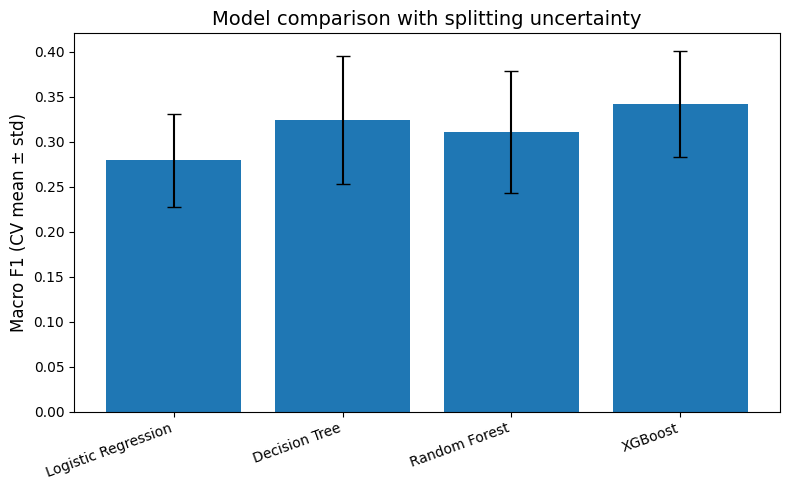

Saved: ../figures/Model comparison scores.png


In [104]:
# Plot means and Stds
plt.figure(figsize=(8,5))

x = np.arange(len(cv_df))
means = cv_df["cv_mean_macro_f1"].values
stds = cv_df["cv_std_macro_f1"].values

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, cv_df["model"], rotation=20, ha="right")
plt.ylabel("Macro F1 (CV mean ± std)")
plt.title("Model comparison with splitting uncertainty")

save_show_plt(fig_dir / "Model comparison scores.png")

#### Results & Comparison

In [105]:
results = [
    {
        "model": "Baseline",
        "test_accuracy": base_acc,
        "test_recall": base_rec,
        "test_macro_f1": base_f1,
        "test_mean_macro_f1": base_test_mean,
        "test_std_macro_f1": base_test_std,
        "test_macro_fbeta2": base_fbeta
    },
    {
        "model": "Logistic Regression",
        "test_accuracy": acc_log,
        "test_recall": rec_log,
        "test_macro_f1": f1_log,
        "test_mean_macro_f1": log_test_mean,
        "test_std_macro_f1": log_test_std,
        "test_macro_fbeta2": fbeta_log
    },
    {
        "model": "Decision Tree",
        "test_accuracy": acc_dt,
        "test_recall": rec_dt,
        "test_macro_f1": f1_dt,
        "test_mean_macro_f1": dt_test_mean,
        "test_std_macro_f1": dt_test_std,
        "test_macro_fbeta2": fbeta_dt
    },
    {
        "model": "Random Forest",
        "test_accuracy": acc_rf,
        "test_recall": rec_rf,
        "test_macro_f1": f1_rf,
        "test_mean_macro_f1": rf_test_mean,
        "test_std_macro_f1": rf_test_std,
        "test_macro_fbeta2": fbeta_rf
    },
    {
        "model": "XGBoost",
        "test_accuracy": acc_xgb,
        "test_recall": rec_xgb,
        "test_macro_f1": f1_xgb,
        "test_mean_macro_f1": xgb_test_mean,
        "test_std_macro_f1": xgb_test_std,
        "test_macro_fbeta2": fbeta_xgb
    }
]

results_df = pd.DataFrame(results)

base_row = results_df["model"].eq("Baseline")
base_mean = results_df.loc[base_row, "test_mean_macro_f1"].iloc[0]
base_std  = results_df.loc[base_row, "test_std_macro_f1"].iloc[0]

denom = np.sqrt(results_df["test_std_macro_f1"]**2 + base_std**2)
results_df["sigma_above_baseline"] = (results_df["test_mean_macro_f1"] - base_mean) / denom

results_df.loc[base_row, "sigma_above_baseline"] = 0.0

# prevent std=0
results_df.replace([np.inf, -np.inf], np.nan, inplace=True)
results_df["sigma_above_baseline"] = results_df["sigma_above_baseline"].round(2)

display(results_df)

,model,test_accuracy,test_recall,test_macro_f1,test_mean_macro_f1,test_std_macro_f1,test_macro_fbeta2,sigma_above_baseline
0,Baseline,0.686516,0.200000,0.162825,0.163255,0.000479,0.183263,0.00
1,Logistic Regression,0.457110,0.386891,0.289467,0.288255,0.003497,0.318387,35.42
2,Decision Tree,0.714587,0.291973,0.315486,0.318403,0.012597,0.294878,12.31
3,Random Forest,0.707570,0.327465,0.362638,0.366584,0.007607,0.336266,26.68
4,XGBoost,0.726783,0.328775,0.369641,0.371353,0.007769,0.337947,26.73


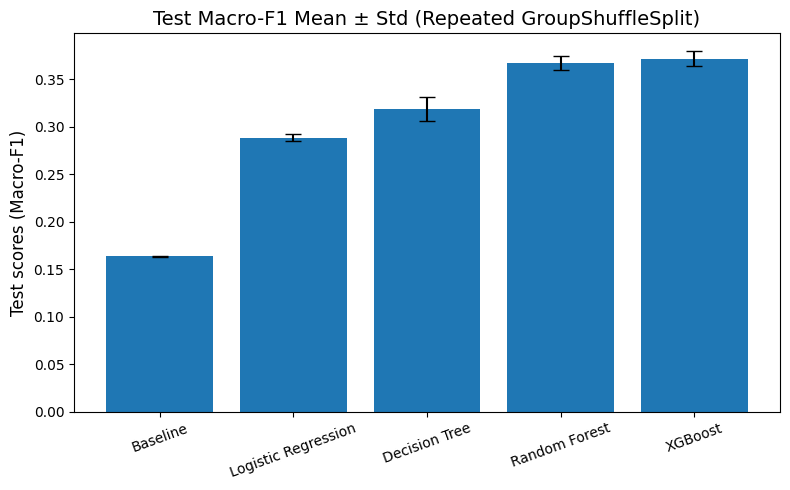

Saved: ../figures/Test scores for all models.png


In [106]:
# Plot test scores comparison
plt.figure(figsize=(8,5))

x = np.arange(len(results_df))
plt.bar(results_df["model"], results_df["test_mean_macro_f1"], yerr=results_df["test_std_macro_f1"], capsize=6)
plt.xticks(rotation=20)
plt.ylabel("Test scores (Macro-F1)")
plt.title("Test Macro-F1 Mean ± Std (Repeated GroupShuffleSplit)")

save_show_plt(fig_dir / "Test scores for all models.png")

### Outlook & Interpretation

According to the comparison, XGBoost is the best because:
1. It has the highest test Mcaro-F1. (Macro-F1 is the best metric for multi-class imbalanced data)
2. It has consistently strong performance in CV with high average scores. Though its mean score is a little bit lower than DT, it has a lower std and is more stable.
3. The model has reasonable complexity, can handle nonlinearity, and incorporates regularization mechanisms. (Less likely to overfit than DT; better suited for this multi-class, high-dimensional sparse features)
4. It has the highes final test accuracy.

#### Confusion Matrix of XGBoost

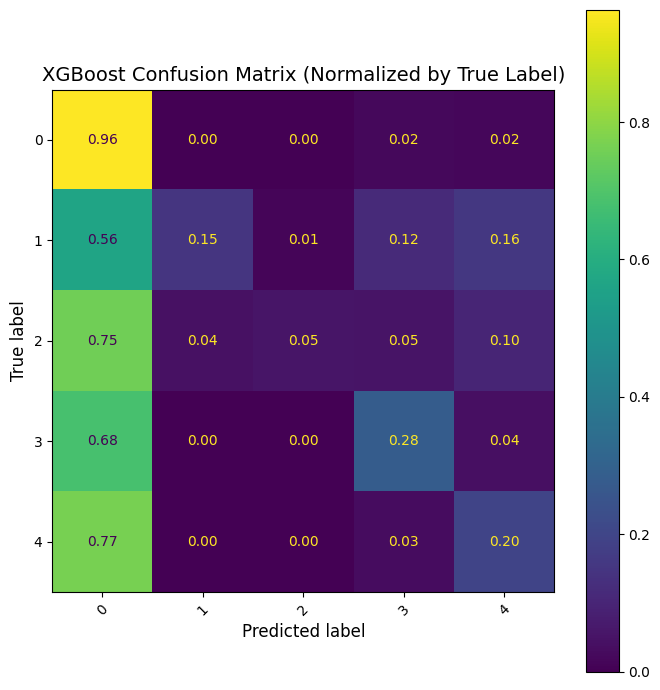

Saved: ../figures/XGBoost Confusion Matrix.png


In [110]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7,7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_xgb,
    normalize="true",
    values_format=".2f",
    display_labels=final_xgb_pipe.classes_ if hasattr(final_xgb_pipe, "classes_") else None,
    xticks_rotation=45,
    ax=ax
)
ax.set_title("XGBoost Confusion Matrix (Normalized by True Label)")
plt.tight_layout()

save_show_plt(fig_dir / "XGBoost Confusion Matrix.png")

#### Global F1 (1): Permutatioon Importance

Permutation importance is computationally expensive, as it requires repeatedly perturbing each feature and re-evaluating model performance.  
Given the large size of the test set and the high dimensionality induced by one-hot encoding, permutation importance was estimated on a random subsample of 1,000 test instances with 5 repeats.   
This provides a reliable approximation of feature importance while significantly reducing computational cost.  
The subsample was drawn from the held-out test set, ensuring that no information leakage from the training data occurred.  

,feature,perm_importance_mean,perm_importance_std
0,cat__intake_type_Public Assist,0.044591,0.005203
1,bin__has_name,0.030066,0.002511
2,num__age_upon_intake_days,0.015636,0.016412
3,cat__month_9,0.008511,0.003486
4,cat__animal_type_Dog,0.008473,0.005870
5,cat__intake_type_Owner Surrender,0.008213,0.004664
6,cat__animal_type_Cat,0.007763,0.001858
7,cat__sex_upon_intake_Intact Male,0.006793,0.003375
8,cat__intake_condition_Normal,0.006787,0.009090
9,cat__breed_Domestic Shorthair Mix,0.005792,0.001985


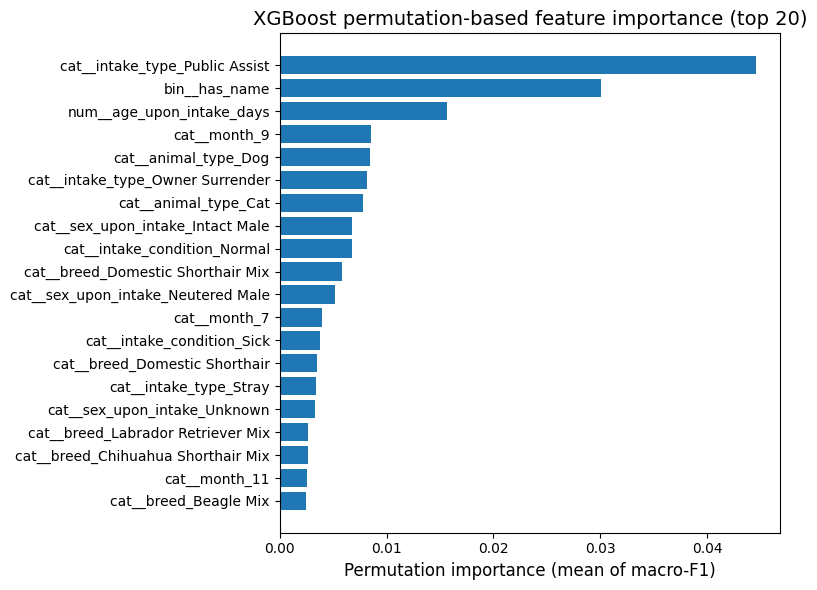

Saved: ../figures/Permutation Importance.png


In [111]:
from sklearn.inspection import permutation_importance

# Get the preprocessor and model
preprocessor = final_xgb_pipe.named_steps["preprocess"]
xgb_clf      = final_xgb_pipe.named_steps["model"]

# Select a sample and preprocess the X_test sample
X_test_sample = X_test.sample(1000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]
X_test_sample_proc = preprocessor.transform(X_test_sample)
# Label encode y_test_sample
y_test_sample_xgb = le_xgb.transform(y_test_sample)

# Use macro-F1 as the score for permutation importance
perm_result = permutation_importance(
    estimator = xgb_clf,
    X = X_test_sample_proc,
    y = y_test_sample_xgb,
    scoring = "f1_macro",
    n_repeats = 5,
    random_state = 42,
    n_jobs = -1
)

feature_names = preprocessor.get_feature_names_out()

perm_importance = pd.DataFrame({
    "feature": feature_names,
    "perm_importance_mean": perm_result.importances_mean,
    "perm_importance_std": perm_result.importances_std
})
perm_importance = perm_importance.sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

display(perm_importance.head(20))

# Plot permutation importances
top_n = 20
pi_top = perm_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(pi_top["feature"], pi_top["perm_importance_mean"])
plt.xlabel("Permutation importance (mean of macro-F1)")
plt.title("XGBoost permutation-based feature importance (top 20)")
save_show_plt(fig_dir / "Permutation Importance.png")    

#### Global F1 (2): Feature importances

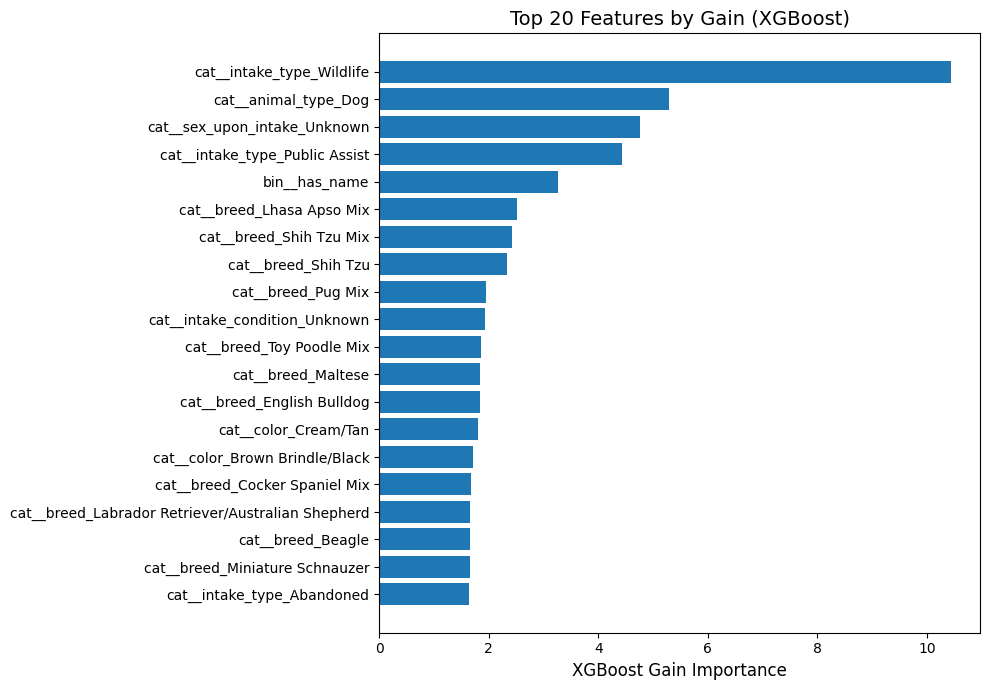

Saved: ../figures/Feature Importance by Gain (XGBoost).png


In [113]:
# Get the XGBClassifier from pipeline
booster = xgb_clf.get_booster()

gain_dict = booster.get_score(importance_type = 'gain')
gain_importance = pd.Series(gain_dict)
gain_importance.index = gain_importance.index.map(lambda s: int(s[1:]))

# Match all features
gain_importance = gain_importance.reindex(
    range(len(feature_names)),
    fill_value = 0
)
gain_importance.index = feature_names

gain_importance = gain_importance.sort_values(ascending=False)

topk = 20
top_gain = gain_importance.head(topk).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_gain.index, top_gain.values)
ax.set_xlabel("XGBoost Gain Importance")
ax.set_title(f"Top {topk} Features by Gain (XGBoost)")
save_show_plt(fig_dir / "Feature Importance by Gain (XGBoost).png")

#### Global F1 (3): Global SHAP

I also use the subsample from the test set for SHAP calculations due to the high computational cost in multiclass tree-based models.

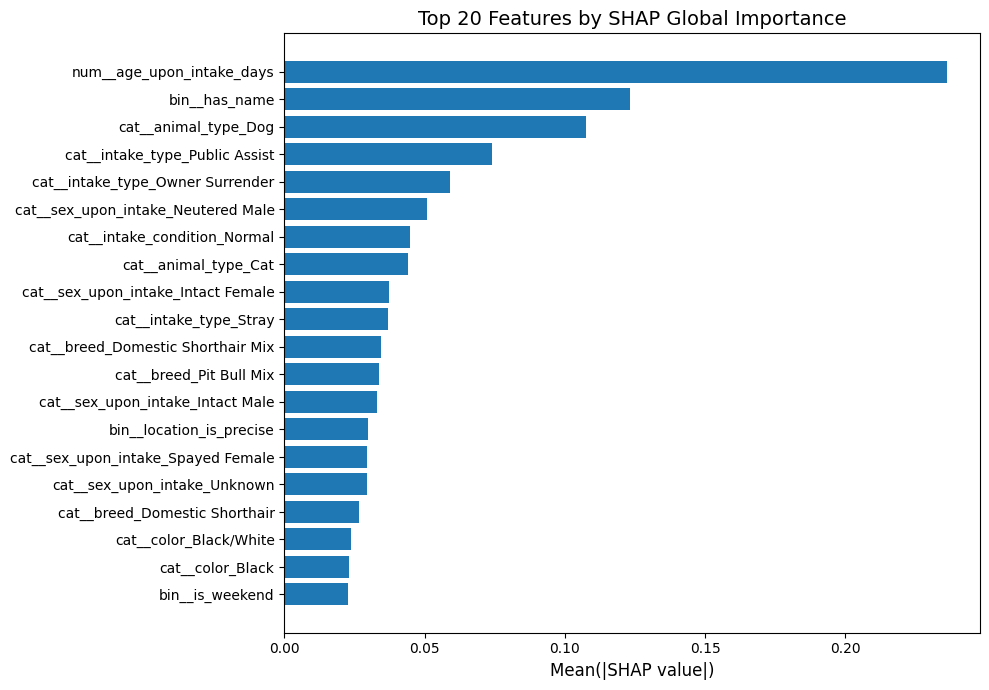

Saved: ../figures/XGB SHAP Global Importance.png


In [115]:
import shap

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test_sample_proc, check_additivity=False)

shap_global_importance = np.mean(np.abs(shap_values.values), axis=0)
# Make sure it's 1-dimensional
shap_global_importance = np.mean(
    np.abs(shap_values.values),
    axis=(0, 2) 
)

shap_importance = pd.Series(shap_global_importance, index=feature_names)
shap_importance = shap_importance.sort_values(ascending=False)

topk = 20
top_shap = shap_importance.head(topk).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_shap.index, top_shap.values)
ax.set_xlabel("Mean(|SHAP value|)")
ax.set_title(f"Top {topk} Features by SHAP Global Importance")
save_show_plt(fig_dir / "XGB SHAP Global Importance.png")

#### Local SHAP

True label: Adoption
Model prediction prob: [0.89167696 0.0077131  0.01841777 0.00618564 0.0760065 ]
Pred class index: 0


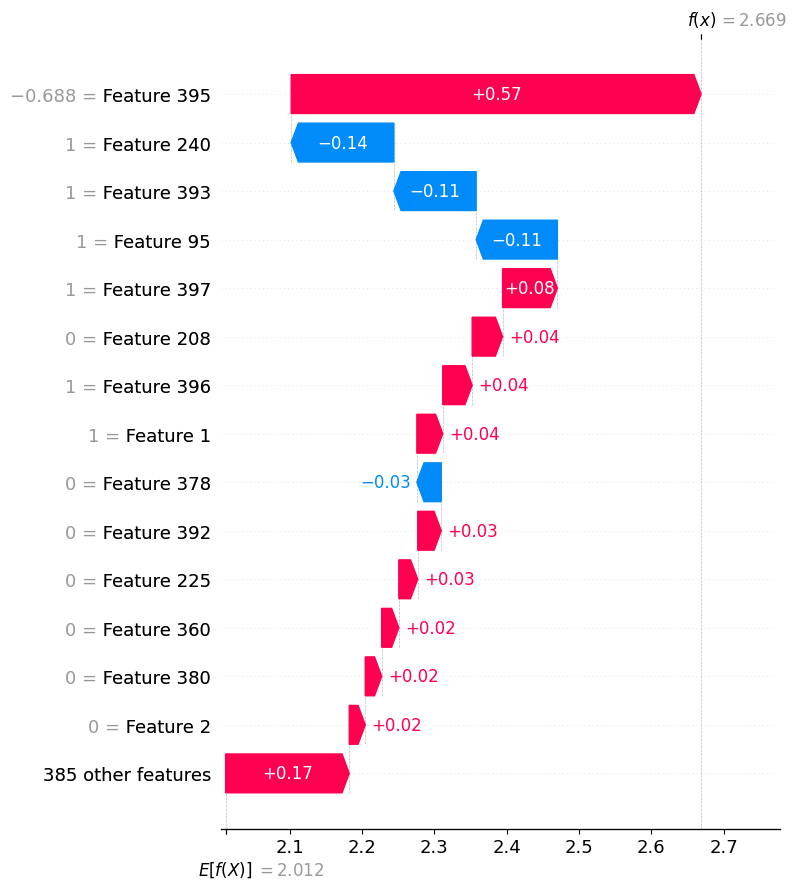

Saved: ../figures/waterfall_i209_class0.png


In [116]:
# Choose a random test sample
i = 209

prob_sample = xgb_clf.predict_proba(X_test_sample_proc)
pred_class = prob_sample.argmax(axis=1)   

print("True label:", y_test_sample.iloc[i])
print("Model prediction prob:", prob_sample[i])
print("Pred class index:", pred_class[i])

shap.plots.waterfall(shap_values[i, :, pred_class[i]], max_display=15, show=False)
save_show_plt(fig_dir / f"waterfall_i{i}_class{pred_class[i]}.png")
plt.close()

### Save Results

In [59]:
from pathlib import Path
import joblib
from sklearn.metrics import classification_report

# Prepare directories
PROJECT_ROOT = Path.cwd().resolve().parent
RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "predictions").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "models").mkdir(parents=True, exist_ok=True)

# 1. Save per-sample predictions
pred_df = pd.DataFrame({
    "animal_id": groups.iloc[test_idx].values,   # group id
    "y_true": y_test.values,
    "y_pred": y_test_pred_xgb,
})

# save predicted probabilities
y_test_proba = final_xgb_pipe.predict_proba(X_test)
class_names = le_xgb.inverse_transform(
    final_xgb_pipe.named_steps["model"].classes_
)

proba_df = pd.DataFrame(
    y_test_proba,
    columns=[f"proba_{c}" for c in class_names]
)

pred_df = pd.concat(
    [pred_df.reset_index(drop=True), proba_df.reset_index(drop=True)],
    axis=1
)

pred_path = RESULTS_DIR / "predictions" / "xgb_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)

# 2. Save metrics
metrics = {
    "model": "XGBoost",
    "test_accuracy": acc_xgb,
    "test_recall_macro": rec_xgb,
    "test_macro_f1": f1_xgb,
    "test_macro_fbeta2": fbeta_xgb,
}

metrics_path = RESULTS_DIR / "metrics" / "xgb_test_metrics.json"
pd.Series(metrics).to_json(metrics_path)

# classification report
report_txt = classification_report(y_test, y_test_pred_xgb, zero_division=0)
with open(RESULTS_DIR / "metrics" / "xgb_classification_report.txt", "w") as f:
    f.write(report_txt)

# 3. Save trained model
joblib.dump(
    final_xgb_pipe,
    RESULTS_DIR / "models" / "final_xgb_pipeline.joblib"
)

print("Saved:")
print(" -", pred_path)
print(" -", metrics_path)
print(" - model artifact")

Saved:
 - /Users/wyq0209/Desktop/Brown/25Fall DATA1030/data1030-fall2025/final_project_animal_adoption/results/predictions/xgb_test_predictions.csv
 - /Users/wyq0209/Desktop/Brown/25Fall DATA1030/data1030-fall2025/final_project_animal_adoption/results/metrics/xgb_test_metrics.json
 - model artifact
